# F1-SIS: Safety Car / VSC Probabilistic Forecasting Module

**Capstone Project: Formula 1 Strategy Intelligence System (F1-SIS)**  
**Module: SC/VSC Probability Model** | **Version: 1.0**

---

> **Central Principle:**  
> *The model output is a **probability**, not a Boolean.*  
> Boolean labels are ground-truth for training/evaluation only.  
> The model always outputs a calibrated probability $P \in [0, 1]$.

---

## Table of Contents

1. [Project Objective](#1-project-objective)
2. [Literature Foundation](#2-literature-foundation)
3. [Problem Formulation](#3-problem-formulation)
4. [Configuration](#4-configuration)
5. [Imports and Dependencies](#5-imports-and-dependencies)
6. [Data Loading](#6-data-loading)
7. [TrackStatus Interpretation](#7-trackstatus-interpretation)
8. [Race-Level Timeline Construction](#8-race-level-timeline-construction)
9. [Event Detection](#9-event-detection)
10. [Prediction Target Construction](#10-prediction-target-construction)
11. [Historical Probability Baseline](#11-historical-probability-baseline)
12. [Leakage Prevention](#12-leakage-prevention)
13. [Feature Architecture](#13-feature-architecture)
14. [Temporal Train / Validation / Test Split](#14-temporal-train--validation--test-split)
15. [Rare Event Handling](#15-rare-event-handling)
16. [Hazard Model Formulation](#16-hazard-model-formulation)
17. [Model Development Ladder](#17-model-development-ladder)
18. [Probability Calibration](#18-probability-calibration)
19. [Sequential Race Replay](#19-sequential-race-replay)
20. [Evaluation](#20-evaluation)
21. [Abu Dhabi 2021 Validation](#21-abu-dhabi-2021-validation)
22. [Italian GP 2021 Validation](#22-italian-gp-2021-validation)
23. [Full Historical Experiment](#23-full-historical-experiment)
24. [Monte Carlo Integration Interface](#24-monte-carlo-integration-interface)
25. [Race State Manager Interface Placeholder](#25-race-state-manager-interface-placeholder)
26. [Limitations](#26-limitations)
27. [Conclusions](#27-conclusions)


---

## 1. Project Objective

### Goal

At the end of every completed race lap $t$, estimate:

$$P(\text{SC starts within next } n \text{ laps} \mid H_t)$$

for horizons $n \in \{1, 3, 5, 10\}$, where $H_t = \{S_1, S_2, \ldots, S_t\}$ is the complete observed race history up to lap $t$.

### Why Probabilistic Output?

The F1-SIS Strategy Engine feeds these probabilities into a **Monte Carlo race simulator**. A binary prediction cannot support this -- only a calibrated probability enables stochastic scenario generation.

### Final System Architecture

```
Historical F1 Data
        |
        v
Historical SC/VSC Baseline (Heilmeier-style)
        |
        v
Live Race State Manager  <- [Developed separately]
        |
        v
Entire observed race history H_t
        |
        v
Temporal Hazard Model
        |
        v
Future SC/VSC hazards: h(t+1), h(t+2), ...
        |
        v
Multi-horizon probabilities: P_1, P_3, P_5, P_10
        |
        v
Probability Calibration
        |
        v
SC/VSC Risk Forecast
        |
        v
Monte Carlo Strategy Simulator
        |
        v
Strategy Intelligence System
```

### Scope

This notebook creates a rigorous SC/VSC probabilistic forecasting module with a clean interface for the Race State Manager and Monte Carlo simulator. It does NOT build the complete F1-SIS.


---

## 2. Literature Foundation

We clearly distinguish **literature-derived methodology** from **F1-SIS design decisions**.

### 2.1 Heilmeier et al. (2020) -- Probabilistic Motorsport Race Simulation

> **Literature-derived:** Provides the primary foundation for:
> - Treating SC/VSC as stochastic events with quantifiable probabilities
> - Race-progress groups to condition SC start probabilities
> - Embedding SC probability into Monte Carlo race simulation
> - Each lap as an independent trial with its own SC hazard
>
> **Our F1-SIS extension:** Adaptive probabilities conditioned on the full observed race history $H_t$, not just race progress.

### 2.2 Sequential Decision-Making Literature

> **Literature-derived:** Motivates the sequential state formulation $H_t = \{S_1, \ldots, S_t\}$ and purely past-observation-based decisions.

### 2.3 Pit Stop Decision Support System (F1-specific)

> **Literature-derived (adapted):** Demonstrates temporal ML for F1, class imbalance handling, and GRU/LSTM-type architectures for sequential F1 lap data.

### 2.4 Large Sequence Models

> **Literature-derived:** Supports using GRU/LSTM representations over the full race history.

### 2.5 XAI in High-Stakes Decisions

> **Literature-derived:** Supports producing interpretable probability outputs for high-stakes motorsport strategy.

### 2.6 What the Papers Do NOT Directly Provide

None of the surveyed papers directly propose the multi-horizon hazard-based SC forecasting architecture implemented here. The formulation:

$$P_n = 1 - \prod_{k=1}^{n}(1 - h(t+k))$$

applied to live F1 sequential data feeding a Monte Carlo simulator is the **F1-SIS design contribution** of this module.


---

## 3. Problem Formulation

### 3.1 Race State and History

$$H_t = \{S_1, S_2, \ldots, S_t\}$$

The model uses **all** of $H_t$. Previous SC/VSC events in the current race are valid information.

### 3.2 SC Hazard Function

$$h(t+k) = P(\text{SC starts at } t+k \mid \text{no SC before } t+k, H_t)$$

### 3.3 Multi-Horizon Cumulative Probabilities

$$P_n = 1 - \prod_{k=1}^{n}(1 - h(t+k)), \quad n \in \{1, 3, 5, 10\}$$

This **automatically enforces monotonicity**: $P_1 \leq P_3 \leq P_5 \leq P_{10}$

### 3.4 Why Not Four Independent Classifiers?

| Problem | Consequence |
|---------|-------------|
| Broken monotonicity | Can produce $P_1 > P_3$ (logically impossible) |
| Ignores conditional structure | Each classifier unaware of subset relationships |
| No survival information | Does not model 'SC hasn't happened yet' |
| Four separate calibration pipelines | Hazard approach requires only one |

### 3.5 Right-Censoring Near Race End

When predicting at lap $t$ near the race end, some horizons extend beyond the final lap. These observations are **right-censored** -- excluded from evaluation rather than treated as confirmed no-events.


---

## 4. Configuration

All key parameters are centralised here for easy modification.


In [1]:
# ============================================================
#  GLOBAL CONFIGURATION
# ============================================================

import os

# --- Data paths ---
DATA_DIR = os.path.join('data_fastf1_v1', 'laps')   # root: one sub-folder per season

VALIDATION_RACES = [
    ('2021', 'Abu_Dhabi_Grand_Prix.csv'),
    ('2021', 'Italian_Grand_Prix.csv'),
]

# --- Forecasting horizons (laps) ---
HORIZONS = [1, 3, 5, 10]

# --- Temporal split (chronological by season) ---
TRAIN_SEASONS  = [2018, 2019, 2020, 2021, 2022]
VAL_SEASONS    = [2023]
TEST_SEASONS   = [2024, 2025]

# --- Random seed ---
RANDOM_SEED = 42

# --- Rare-event handling ---
SC_CLASS_WEIGHT = 'balanced'
FOCAL_GAMMA     = 2.0

# --- Model hyperparameters ---
XGB_N_ESTIMATORS = 300
XGB_MAX_DEPTH    = 5
XGB_LR           = 0.05

# --- Race progress bins (Heilmeier-style baseline) ---
PROGRESS_BINS   = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
PROGRESS_LABELS = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
                   '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

# --- Smoothing for sparse circuit-specific priors ---
LAPLACE_ALPHA = 0.5

# --- Probability clipping (numerical stability) ---
PROB_CLIP_LOW  = 1e-6
PROB_CLIP_HIGH = 1.0 - 1e-6

print('Configuration loaded.')
print(f'  Horizons        : {HORIZONS}')
print(f'  Train seasons   : {TRAIN_SEASONS}')
print(f'  Val seasons     : {VAL_SEASONS}')
print(f'  Test seasons    : {TEST_SEASONS}')
print(f'  Data directory  : {DATA_DIR}')


Configuration loaded.
  Horizons        : [1, 3, 5, 10]
  Train seasons   : [2018, 2019, 2020, 2021, 2022]
  Val seasons     : [2023]
  Test seasons    : [2024, 2025]
  Data directory  : data_fastf1_v1\laps


---

## 5. Imports and Dependencies


In [2]:
import warnings
import time
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

matplotlib.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PALETTE = {
    'sc':       '#E63946',
    'vsc':      '#F4A261',
    'normal':   '#2A9D8F',
    'yellow':   '#FECF00',
    'red_flag': '#9B2226',
}

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss, log_loss,
    roc_auc_score, average_precision_score,
    precision_recall_curve,
    precision_score, recall_score, f1_score,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print(f'XGBoost: {xgb.__version__}')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost NOT available')

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print('CatBoost: available')
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost NOT available')

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    print(f'PyTorch: {torch.__version__}')
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch NOT available -- GRU model skipped')

print('\nAll imports complete.')


XGBoost: 3.4.0
CatBoost: available
PyTorch NOT available -- GRU model skipped

All imports complete.


---

## 6. Data Loading

The raw data is **driver-lap level**: one row per driver per lap.

> **PROVISIONAL DATA ADAPTER:** `load_race_data()` and `load_all_races()` are a temporary layer. In production, the Race State Manager delivers `RaceState_t` directly. This adapter will be replaced without changing downstream interfaces.


In [3]:
def load_race_data(csv_path: str) -> pd.DataFrame:
    # PROVISIONAL DATA ADAPTER -- will be replaced by Race State Manager
    df = pd.read_csv(csv_path, low_memory=False)

    if 'Year' in df.columns and 'GrandPrix' in df.columns:
        gp_name = df['GrandPrix'].iloc[0].replace(' ', '_')
        year    = str(int(df['Year'].iloc[0]))
        df['race_id'] = f'{year}_{gp_name}'
    else:
        df['race_id'] = Path(csv_path).stem

    df['LapNumber']   = pd.to_numeric(df['LapNumber'], errors='coerce')
    df['TrackStatus'] = pd.to_numeric(df['TrackStatus'], errors='coerce').fillna(1).astype(int)

    for col in ['HasSafetyCar', 'HasVSC', 'HasVSCEnding', 'HasYellow',
                'HasGreen', 'HasRedFlag', 'Rainfall']:
        if col in df.columns:
            df[col] = df[col].map(
                lambda x: str(x).strip().lower() in ('true', '1', 'yes')
                if pd.notna(x) else False
            )

    df['source_file'] = str(csv_path)
    return df


def load_all_races(data_dir: str = DATA_DIR,
                   seasons: Optional[List[int]] = None) -> pd.DataFrame:
    # Load all race CSVs from data_dir/year/ subdirectories
    frames    = []
    data_path = Path(data_dir)

    for season_dir in sorted(data_path.iterdir()):
        if not season_dir.is_dir():
            continue
        try:
            yr = int(season_dir.name)
        except ValueError:
            continue
        if seasons is not None and yr not in seasons:
            continue
        for csv_file in sorted(season_dir.glob('*.csv')):
            try:
                frames.append(load_race_data(str(csv_file)))
            except Exception as e:
                print(f'  WARNING: {csv_file.name}: {e}')

    if not frames:
        raise FileNotFoundError(f'No race CSVs found in {data_dir}')

    all_df = pd.concat(frames, ignore_index=True)
    n_races = all_df['race_id'].nunique()
    print(f'Loaded {len(frames)} races | {n_races} unique race IDs | {len(all_df):,} rows')
    return all_df


# Quick validation
sample_df = load_race_data(os.path.join(DATA_DIR, '2021', 'Abu_Dhabi_Grand_Prix.csv'))
print(f'Sample race  : {sample_df["race_id"].iloc[0]}')
print(f'Shape        : {sample_df.shape}')
print(f'Lap range    : {int(sample_df["LapNumber"].min())} -- {int(sample_df["LapNumber"].max())}')
print(f'TrackStatus unique: {sorted(sample_df["TrackStatus"].unique())}')


Sample race  : 2021_Abu_Dhabi_Grand_Prix
Shape        : (1000, 67)
Lap range    : 1 -- 58
TrackStatus unique: [np.int64(1), np.int64(4), np.int64(6), np.int64(12), np.int64(16), np.int64(21), np.int64(24), np.int64(41), np.int64(67), np.int64(71), np.int64(124), np.int64(671)]


---

## 7. TrackStatus Interpretation

### 7.1 Encoding

The `TrackStatus` field is a **concatenation of digit codes**. Each digit represents an active track condition simultaneously:

| Digit | Meaning |
|-------|---------|
| 1 | Green flag / normal racing |
| 2 | Yellow flag sector |
| 4 | Safety Car active |
| 5 | Red Flag |
| 6 | Virtual Safety Car deployed |
| 7 | VSC ending (transition phase) |

### 7.2 Examples Observed in Dataset

| TrackStatus | Digits | Interpretation |
|-------------|--------|---------------|
| 1 | {1} | Normal racing |
| 4 | {4} | Safety Car |
| 124 | {1,2,4} | Green + yellow + SC |
| 6 | {6} | VSC deployed |
| 671 | {6,7,1} | VSC active + ending + green |
| 41 | {4,1} | SC ending phase |
| 1267 | {1,2,6,7} | Complex combined state |

### 7.3 Key Decoding Rules

- **SC active**: digit `4` present
- **VSC active**: digit `6` present (not combined with SC)
- **VSC ending**: digit `7` present
- **IMPORTANT**: `7` alone does NOT represent a new VSC event -- it is the ending phase

### 7.4 Validation

We cross-validate against FastF1's pre-decoded boolean columns (`HasSafetyCar`, `HasVSC`, `HasVSCEnding`) and require >95% agreement.


In [4]:
def decode_track_status(status_int: int) -> Dict[str, bool]:
    # Decode TrackStatus integer into component flags.
    # The field is a digit-concatenation: e.g. 671 = {6, 7, 1}
    digits     = set(str(int(status_int)))
    sc_active  = '4' in digits
    vsc_active = ('6' in digits) and not sc_active
    vsc_ending = '7' in digits
    red_flag   = '5' in digits
    yellow     = '2' in digits
    green      = '1' in digits and not sc_active and not vsc_active and not red_flag
    return {
        'sc_active':   sc_active,
        'vsc_active':  vsc_active,
        'vsc_ending':  vsc_ending,
        'red_flag':    red_flag,
        'yellow_flag': yellow,
        'green':       green,
    }


def apply_track_status_decoder(df: pd.DataFrame) -> pd.DataFrame:
    decoded = df['TrackStatus'].apply(decode_track_status).apply(pd.Series)
    for col in decoded.columns:
        df[col] = decoded[col]
    return df


def validate_decoder(df: pd.DataFrame, race_name: str = '') -> None:
    # Cross-validate decoder against FastF1 pre-decoded columns
    df_check  = apply_track_status_decoder(df.copy())
    sc_agree  = (df_check['sc_active']  == df_check['HasSafetyCar']).mean()
    vsc_agree = (df_check['vsc_active'] == df_check['HasVSC']).mean()
    ve_agree  = (df_check['vsc_ending'] == df_check['HasVSCEnding']).mean()
    ok_sc  = '[OK]' if sc_agree  >= 0.95 else '[!]'
    ok_vsc = '[OK]' if vsc_agree >= 0.95 else '[!]'
    ok_ve  = '[OK]' if ve_agree  >= 0.95 else '[!]'
    print(f'Decoder validation [{race_name}]:')
    print(f'  SC  agreement : {sc_agree:.1%}  {ok_sc}')
    print(f'  VSC agreement : {vsc_agree:.1%} {ok_vsc}')
    print(f'  VSC-ending    : {ve_agree:.1%}  {ok_ve}')


validate_decoder(sample_df, 'Abu Dhabi 2021')

print('\nDecoder demonstration:')
for s in [1, 12, 4, 24, 124, 6, 16, 67, 671, 71, 41, 1267, 2671, 5]:
    d     = decode_track_status(s)
    flags = [k for k, v in d.items() if v]
    print(f'  Status {str(s):>5} -> {', '.join(flags) or 'none'}')


Decoder validation [Abu Dhabi 2021]:
  SC  agreement : 100.0%  [OK]
  VSC agreement : 100.0% [OK]
  VSC-ending    : 100.0%  [OK]

Decoder demonstration:
  Status     1 -> green
  Status    12 -> yellow_flag, green
  Status     4 -> sc_active
  Status    24 -> sc_active, yellow_flag
  Status   124 -> sc_active, yellow_flag
  Status     6 -> vsc_active
  Status    16 -> vsc_active
  Status    67 -> vsc_active, vsc_ending
  Status   671 -> vsc_active, vsc_ending
  Status    71 -> vsc_ending, green
  Status    41 -> sc_active
  Status  1267 -> vsc_active, vsc_ending, yellow_flag
  Status  2671 -> vsc_active, vsc_ending, yellow_flag
  Status     5 -> red_flag


---

## 8. Race-Level Timeline Construction

The raw data is driver-lap level. We aggregate to **race-level** (one row per lap).

**Aggregation rules:**
- SC active if ANY driver's TrackStatus shows SC
- VSC active if ANY driver's TrackStatus shows VSC
- Weather = median across drivers
- Field metrics = aggregate statistics

> **PROVISIONAL:** This aggregation replaces what the Race State Manager will eventually provide. The output schema is stable across this substitution.


In [5]:
def build_race_level_timeline(df: pd.DataFrame) -> pd.DataFrame:
    # PROVISIONAL RACE STATE AGGREGATION -- will be replaced by Race State Manager
    df        = apply_track_status_decoder(df.copy())
    race_laps = sorted(df['LapNumber'].dropna().unique())
    race_id   = df['race_id'].iloc[0]
    rows      = []

    for lap in race_laps:
        lap_df     = df[df['LapNumber'] == lap]
        sc_active  = lap_df['sc_active'].any()
        vsc_active = lap_df['vsc_active'].any()
        vsc_ending = lap_df['vsc_ending'].any()
        red_flag   = lap_df['red_flag'].any()
        yellow     = lap_df['yellow_flag'].any()
        mode_ts    = lap_df['TrackStatus'].mode()
        track_status_raw = int(mode_ts.iloc[0]) if len(mode_ts) > 0 else 1
        n_cars = lap_df['Driver'].nunique()

        weather = {}
        for wc in ['AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'WindSpeed']:
            weather[wc] = lap_df[wc].median() if wc in lap_df.columns else np.nan
        weather['Rainfall'] = lap_df['Rainfall'].any() if 'Rainfall' in lap_df.columns else False

        lt_col = 'LapTimeSeconds'
        if lt_col in lap_df.columns:
            lt_valid        = lap_df[lt_col].dropna()
            lap_time_median = lt_valid.median()
            lap_time_std    = lt_valid.std()
        else:
            lap_time_median = lap_time_std = np.nan

        tyre_age     = lap_df['TyreLife'].median() if 'TyreLife' in lap_df.columns else np.nan
        compound_m   = lap_df['Compound'].mode()
        compound     = compound_m.iloc[0] if len(compound_m) > 0 else 'UNKNOWN'
        pits_in      = lap_df['PitInTime'].notna().sum()  if 'PitInTime'  in lap_df.columns else 0
        pits_out     = lap_df['PitOutTime'].notna().sum() if 'PitOutTime' in lap_df.columns else 0

        gap_col = 'GapToLeaderSeconds'
        if gap_col in lap_df.columns:
            gaps       = pd.to_numeric(lap_df[gap_col], errors='coerce').dropna()
            gap_median = gaps.median()
            gap_max    = gaps.max()
        else:
            gap_median = gap_max = np.nan

        rows.append({
            'race_id': race_id, 'lap': int(lap),
            'track_status_raw': track_status_raw,
            'sc_active': sc_active, 'vsc_active': vsc_active,
            'vsc_ending': vsc_ending, 'red_flag': red_flag, 'yellow_flag': yellow,
            'n_cars': n_cars, 'lap_time_median': lap_time_median, 'lap_time_std': lap_time_std,
            'tyre_age_median': tyre_age, 'dominant_compound': compound,
            'pits_in': pits_in, 'pits_out': pits_out,
            'gap_median': gap_median, 'gap_max': gap_max,
            **{k: v for k, v in weather.items()},
        })

    tl = pd.DataFrame(rows).sort_values('lap').reset_index(drop=True)
    tl['max_cars_so_far']       = tl['n_cars'].cummax()
    tl['retirements_cumulative']= (tl['max_cars_so_far'] - tl['n_cars']).clip(lower=0)
    tl['total_laps']            = int(race_laps[-1])
    tl['race_progress']         = tl['lap'] / tl['total_laps']
    return tl


# Build Abu Dhabi 2021
abu_dhabi_df = load_race_data(os.path.join(DATA_DIR, '2021', 'Abu_Dhabi_Grand_Prix.csv'))
abu_dhabi_tl = build_race_level_timeline(abu_dhabi_df)
print(f'Abu Dhabi 2021 -- Laps: {len(abu_dhabi_tl)} | SC laps: {abu_dhabi_tl["sc_active"].sum()} | '
      f'VSC laps: {abu_dhabi_tl["vsc_active"].sum()}')
print(abu_dhabi_tl[['lap','track_status_raw','sc_active','vsc_active','vsc_ending','race_progress']].to_string())


Abu Dhabi 2021 -- Laps: 58 | SC laps: 7 | VSC laps: 4
    lap  track_status_raw  sc_active  vsc_active  vsc_ending  race_progress
0     1                 1      False       False       False       0.017241
1     2                 1      False       False       False       0.034483
2     3                 1      False       False       False       0.051724
3     4                 1      False       False       False       0.068966
4     5                 1      False       False       False       0.086207
5     6                 1      False       False       False       0.103448
6     7                 1      False       False       False       0.120690
7     8                 1      False       False       False       0.137931
8     9                 1      False       False       False       0.155172
9    10                 1      False       False       False       0.172414
10   11                 1      False       False       False       0.189655
11   12                 1      Fal

---

## 9. Event Detection

### SC Event Start Rule

**SC START** = previous lap `sc_active = False` AND current lap `sc_active = True`

Consecutive SC-active laps belong to the **same** SC event.

### VSC Event Start Rule

**VSC START** = `vsc_active` newly becomes True (digit `6` newly present)

The `vsc_ending` phase (digit `7`) belongs to the **same VSC event** as the preceding active phase.

### Edge Cases

| Case | Handling |
|------|----------|
| SC active at prediction time | Disable prediction |
| VSC active at prediction time | Disable prediction |
| No future SC | next_sc_lap = NaN, targets = 0 |
| Horizon > race end | Right-censored -- excluded from evaluation |
| Red flag | Disable prediction |


In [6]:
def detect_sc_events(timeline: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Detect SC events from race-level timeline
    tl = timeline.copy().sort_values('lap').reset_index(drop=True)
    tl['sc_prev']     = tl['sc_active'].shift(1, fill_value=False)
    tl['sc_start']    = (~tl['sc_prev']) & tl['sc_active']
    tl['sc_event_id'] = tl['sc_start'].cumsum().where(tl['sc_active'], 0)

    events = []
    for eid, grp in tl[tl['sc_active']].groupby('sc_event_id'):
        events.append({
            'race_id':      tl['race_id'].iloc[0],
            'sc_event_id':  eid,
            'sc_start_lap': int(grp['lap'].min()),
            'sc_end_lap':   int(grp['lap'].max()),
            'sc_duration':  int(grp['lap'].count()),
        })

    sc_events = pd.DataFrame(events)
    tl.drop(columns=['sc_prev'], inplace=True)
    return tl, sc_events


def detect_vsc_events(timeline: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Detect VSC events -- includes vsc_active and vsc_ending phases in one event
    tl = timeline.copy().sort_values('lap').reset_index(drop=True)
    tl['vsc_intervention']  = tl['vsc_active'] | tl['vsc_ending']
    tl['vsc_prev_active']   = tl['vsc_active'].shift(1, fill_value=False)
    tl['vsc_prev_ending']   = tl['vsc_ending'].shift(1, fill_value=False)
    tl['vsc_start']         = tl['vsc_active'] & (~tl['vsc_prev_active']) & (~tl['vsc_prev_ending'])
    tl['vsc_event_id_raw']  = tl['vsc_start'].cumsum()
    tl['vsc_event_id']      = tl['vsc_event_id_raw'].where(tl['vsc_intervention'], 0)

    events = []
    for eid, grp in tl[tl['vsc_intervention']].groupby('vsc_event_id'):
        events.append({
            'race_id':       tl['race_id'].iloc[0],
            'vsc_event_id':  eid,
            'vsc_start_lap': int(grp['lap'].min()),
            'vsc_end_lap':   int(grp['lap'].max()),
            'vsc_duration':  int(grp['lap'].count()),
        })

    vsc_events = pd.DataFrame(events)
    tl.drop(columns=['vsc_prev_active', 'vsc_prev_ending', 'vsc_event_id_raw'], inplace=True)
    return tl, vsc_events


def build_event_table(timeline: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Apply both SC and VSC detection. Returns (timeline, sc_events, vsc_events)
    tl, sc_events  = detect_sc_events(timeline)
    tl, vsc_events = detect_vsc_events(tl)
    return tl, sc_events, vsc_events


# Apply to Abu Dhabi 2021
abu_tl, abu_sc_events, abu_vsc_events = build_event_table(abu_dhabi_tl)

print('=== Abu Dhabi 2021 SC Events ===')
print(abu_sc_events.to_string() if len(abu_sc_events) > 0 else '  No SC events')
print('\n=== Abu Dhabi 2021 VSC Events ===')
print(abu_vsc_events.to_string() if len(abu_vsc_events) > 0 else '  No VSC events')


=== Abu Dhabi 2021 SC Events ===
                     race_id  sc_event_id  sc_start_lap  sc_end_lap  sc_duration
0  2021_Abu_Dhabi_Grand_Prix            1            51          57            7

=== Abu Dhabi 2021 VSC Events ===
                     race_id  vsc_event_id  vsc_start_lap  vsc_end_lap  vsc_duration
0  2021_Abu_Dhabi_Grand_Prix             1             34           38             5


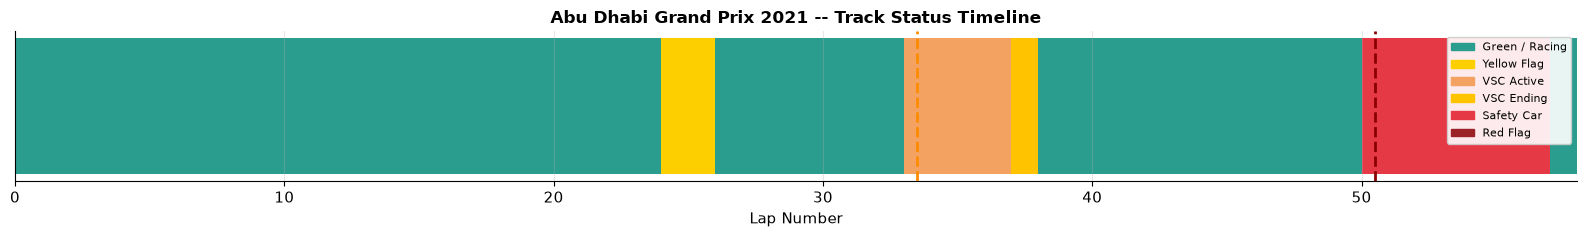

In [7]:
def plot_track_status_timeline(tl: pd.DataFrame, title: str = '') -> None:
    # Colour-coded lap-by-lap track status timeline
    fig, ax = plt.subplots(figsize=(16, 2.5))
    for _, row in tl.iterrows():
        if row['sc_active']:               color = PALETTE['sc']
        elif row['vsc_active']:            color = PALETTE['vsc']
        elif row.get('vsc_ending', False): color = '#FFC300'
        elif row.get('red_flag', False):   color = PALETTE['red_flag']
        elif row.get('yellow_flag', False):color = PALETTE['yellow']
        else:                              color = PALETTE['normal']
        ax.barh(0, 1, left=row['lap'] - 1, height=0.8, color=color, edgecolor='none')

    if 'sc_start' in tl.columns:
        for s in tl[tl['sc_start'] == True]['lap']:
            ax.axvline(s - 0.5, color='darkred', linewidth=2, linestyle='--')
    if 'vsc_start' in tl.columns:
        for v in tl[tl['vsc_start'] == True]['lap']:
            ax.axvline(v - 0.5, color='darkorange', linewidth=2, linestyle='--')

    legend_patches = [
        mpatches.Patch(color=PALETTE['normal'],   label='Green / Racing'),
        mpatches.Patch(color=PALETTE['yellow'],   label='Yellow Flag'),
        mpatches.Patch(color=PALETTE['vsc'],      label='VSC Active'),
        mpatches.Patch(color='#FFC300',           label='VSC Ending'),
        mpatches.Patch(color=PALETTE['sc'],       label='Safety Car'),
        mpatches.Patch(color=PALETTE['red_flag'], label='Red Flag'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_xlabel('Lap Number')
    ax.set_title(title or tl['race_id'].iloc[0], fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.set_xlim(0, tl['lap'].max())
    plt.tight_layout()
    plt.show()


plot_track_status_timeline(abu_tl, 'Abu Dhabi Grand Prix 2021 -- Track Status Timeline')


=== Italian GP 2021 SC Events ===
                   race_id  sc_event_id  sc_start_lap  sc_end_lap  sc_duration
0  2021_Italian_Grand_Prix            1            25          30            6

=== Italian GP 2021 VSC Events ===
                   race_id  vsc_event_id  vsc_start_lap  vsc_end_lap  vsc_duration
0  2021_Italian_Grand_Prix             1              1            2             2
1  2021_Italian_Grand_Prix             2             42           44             3


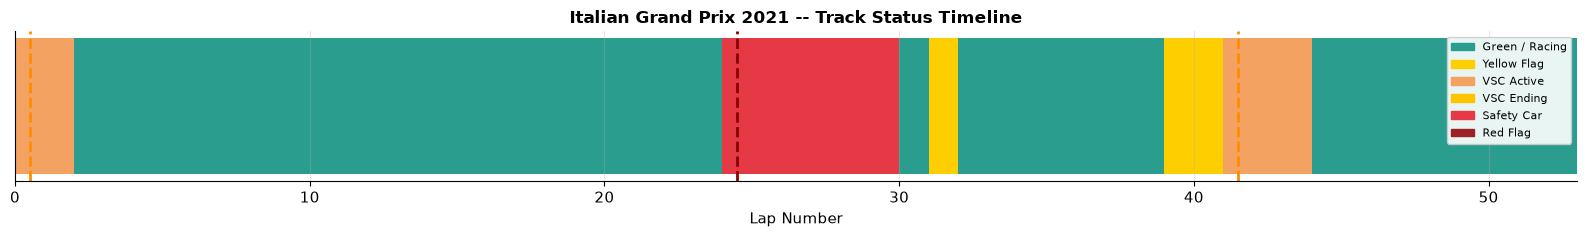

In [8]:
# Italian GP 2021
italian_df = load_race_data(os.path.join(DATA_DIR, '2021', 'Italian_Grand_Prix.csv'))
italian_tl = build_race_level_timeline(italian_df)
italian_tl, italian_sc_events, italian_vsc_events = build_event_table(italian_tl)

print('=== Italian GP 2021 SC Events ===')
print(italian_sc_events.to_string() if len(italian_sc_events) > 0 else '  No SC events')
print('\n=== Italian GP 2021 VSC Events ===')
print(italian_vsc_events.to_string() if len(italian_vsc_events) > 0 else '  No VSC events')

plot_track_status_timeline(italian_tl, 'Italian Grand Prix 2021 -- Track Status Timeline')


---

## 10. Prediction Target Construction

For each prediction point (end of lap $t$):

1. Find time to **next** SC/VSC event start
2. Construct Boolean horizon targets (ground truth for training/evaluation only)
3. Mark right-censored horizons (horizon extends beyond race end)
4. Disable prediction during active interventions


In [9]:
def build_prediction_targets(tl: pd.DataFrame,
                             sc_events: pd.DataFrame,
                             vsc_events: pd.DataFrame,
                             horizons: List[int] = HORIZONS) -> pd.DataFrame:
    # Build prediction target columns for each race lap
    tl = tl.copy().sort_values('lap').reset_index(drop=True)
    total_laps     = int(tl['lap'].max())
    sc_start_laps  = sorted(sc_events['sc_start_lap'].tolist())  if len(sc_events)  > 0 else []
    vsc_start_laps = sorted(vsc_events['vsc_start_lap'].tolist()) if len(vsc_events) > 0 else []

    for n in horizons:
        tl[f'SC_next_{n}']  = 0
        tl[f'VSC_next_{n}'] = 0
        tl[f'censored_{n}'] = False

    tl['prediction_active']   = True
    tl['next_sc_lap']         = np.nan
    tl['laps_until_next_sc']  = np.nan
    tl['next_vsc_lap']        = np.nan
    tl['laps_until_next_vsc'] = np.nan

    for idx, row in tl.iterrows():
        t = row['lap']
        if row['sc_active'] or row['vsc_active'] or row['red_flag']:
            tl.at[idx, 'prediction_active'] = False
            continue

        future_sc  = [l for l in sc_start_laps  if l > t]
        future_vsc = [l for l in vsc_start_laps if l > t]

        if future_sc:
            tl.at[idx, 'next_sc_lap']        = future_sc[0]
            tl.at[idx, 'laps_until_next_sc'] = future_sc[0] - t
        if future_vsc:
            tl.at[idx, 'next_vsc_lap']        = future_vsc[0]
            tl.at[idx, 'laps_until_next_vsc'] = future_vsc[0] - t

        for n in horizons:
            if t + n > total_laps:
                tl.at[idx, f'censored_{n}'] = True  # Right-censored
                continue
            tl.at[idx, f'SC_next_{n}']  = int(any(t < l <= t + n for l in sc_start_laps))
            tl.at[idx, f'VSC_next_{n}'] = int(any(t < l <= t + n for l in vsc_start_laps))

    return tl


abu_tl = build_prediction_targets(abu_tl, abu_sc_events, abu_vsc_events)

print('Abu Dhabi 2021 -- Target summary:')
pred = abu_tl[abu_tl['prediction_active']]
print(f'  Total laps             : {len(abu_tl)}')
print(f'  Prediction-active laps : {len(pred)}')
for n in HORIZONS:
    valid = abu_tl[~abu_tl[f'censored_{n}']] 
    vp    = valid[valid['prediction_active']]
    print(f'  SC_next_{n:>2}: {int(vp[f"SC_next_{n}"].sum())} positive / {len(vp)} uncensored')


Abu Dhabi 2021 -- Target summary:
  Total laps             : 58
  Prediction-active laps : 47
  SC_next_ 1: 1 positive / 46 uncensored
  SC_next_ 3: 3 positive / 46 uncensored
  SC_next_ 5: 5 positive / 46 uncensored
  SC_next_10: 8 positive / 44 uncensored


---

## 11. Historical Probability Baseline

Progressive baseline following the Heilmeier et al. philosophy.

| Model | Conditioning | Type |
|-------|-------------|------|
| B0 | Global SC rate | Literature-derived |
| B1 | SC rate by race progress | Literature-derived (Heilmeier) |
| B2 | Circuit + race progress | F1-SIS extension |
| B3 | Circuit + progress + race history | F1-SIS extension |

> **IMPORTANT:** Historical priors are always computed using only **training races**. The test race must never enter the prior calculation.

> **Heilmeier calibration note:** Heilmeier et al. used 2014--2019 data. We do NOT assume those probabilities apply to modern F1 (2018--2025). We estimate our own priors and compare.


In [10]:
def build_historical_prior(all_race_timelines: Dict[str, pd.DataFrame],
                           train_race_ids: List[str],
                           progress_bins: List[float] = PROGRESS_BINS,
                           progress_labels: List[str] = PROGRESS_LABELS,
                           laplace_alpha: float = LAPLACE_ALPHA) -> Dict[str, Any]:
    # Build historical SC/VSC priors from TRAINING races only (leakage control)
    train_tls = [all_race_timelines[r] for r in train_race_ids if r in all_race_timelines]
    if not train_tls:
        raise ValueError('No training timelines found')

    combined = pd.concat(train_tls, ignore_index=True)
    valid    = combined[combined['prediction_active'] == True].copy()

    valid['progress_bin'] = pd.cut(
        valid['race_progress'], bins=progress_bins, labels=progress_labels, include_lowest=True
    )

    # B0: Global SC probability per lap
    global_sc_prob = float(valid['sc_start'].mean()) if 'sc_start' in valid.columns else 0.0

    # B1: By race progress (Heilmeier-style)
    prog_sc = valid.groupby('progress_bin', observed=True)['sc_start'].agg(['sum', 'count'])
    prog_sc.columns = ['sc_starts', 'laps']
    prog_sc['sc_prob'] = (
        (prog_sc['sc_starts'] + laplace_alpha) / (prog_sc['laps'] + 2 * laplace_alpha)
    )

    # B2: Circuit-specific
    valid['circuit'] = valid['race_id'].apply(lambda x: '_'.join(str(x).split('_')[1:]))
    circ_sc = valid.groupby('circuit')['sc_start'].agg(['sum', 'count'])
    circ_sc.columns = ['sc_starts', 'laps']
    circ_sc['sc_prob'] = (
        (circ_sc['sc_starts'] + laplace_alpha) / (circ_sc['laps'] + 2 * laplace_alpha)
    )

    return {
        'global_sc_prob':   global_sc_prob,
        'progress_sc_prob': prog_sc['sc_prob'],
        'circuit_sc_prob':  circ_sc['sc_prob'].to_dict(),
        'valid_laps':       len(valid),
        'total_sc_starts':  int(valid['sc_start'].sum()) if 'sc_start' in valid.columns else 0,
    }


def train_baseline(tl: pd.DataFrame, baseline_priors=None, horizon: int = 5) -> pd.Series:
    # MODEL 0: Heilmeier-style race-progress-conditioned baseline
    if baseline_priors is None:
        return pd.Series(0.05, index=tl.index)
    progress_sc = baseline_priors['progress_sc_prob']
    global_prob = baseline_priors['global_sc_prob']
    def get_h(prog):
        for i in range(len(PROGRESS_BINS) - 1):
            if PROGRESS_BINS[i] <= prog <= PROGRESS_BINS[i + 1]:
                return float(progress_sc.get(PROGRESS_LABELS[i], global_prob))
        return float(global_prob)
    hazards  = tl['race_progress'].apply(get_h)
    cum_prob = 1 - (1 - hazards) ** horizon
    return cum_prob.clip(PROB_CLIP_LOW, PROB_CLIP_HIGH)


print('Historical prior and baseline functions defined.')


Historical prior and baseline functions defined.


---

## 12. Leakage Prevention

This is a **critical correctness requirement**.

### 12.1 What is Allowed at Prediction Time t

| Feature type | Allowed? | Reason |
|-------------|----------|--------|
| Race progress at lap t | YES | Known at end of lap t |
| Cumulative SC count up to t | YES | Already happened |
| Laps since last SC (up to t) | YES | Already happened |
| Rolling stats trailing from t | YES | Causal window |
| Historical circuit priors | YES | From training races only |
| TrackStatus of lap t+1 | NO | Future leakage |
| Final SC count of the race | NO | Future leakage |
| Scaler fit on test race | NO | Distribution leakage |
| Centred rolling window around t | NO | Uses future data |

### 12.2 Preprocessing Protocol

```
scaler.fit(X_train only)       # NEVER fit on full dataset
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)    # same fitted scaler
X_test_scaled  = scaler.transform(X_test)   # same fitted scaler
```


In [11]:
FORBIDDEN_FEATURES = [
    'sc_start', 'vsc_start',
    'SC_next_1', 'SC_next_3', 'SC_next_5', 'SC_next_10',
    'VSC_next_1', 'VSC_next_3', 'VSC_next_5', 'VSC_next_10',
    'next_sc_lap', 'next_vsc_lap',
    'laps_until_next_sc', 'laps_until_next_vsc',
]


def check_temporal_leakage(feature_cols: List[str]) -> None:
    print('=== Temporal Leakage Audit ===')
    found = False
    for f in FORBIDDEN_FEATURES:
        if f in feature_cols:
            print(f'  [LEAKAGE] {f!r} is a future-derived column!')
            found = True
    if not found:
        print('  [OK] No forbidden future columns in feature set')
    print('  [OK] Rolling window features use causal trailing windows')
    print('REMINDER: Scalers must be fit on training data only.')
    print('          Historical priors must exclude the test race.')
    print('=' * 35)


print('Leakage prevention framework defined.')


Leakage prevention framework defined.


---

## 13. Feature Architecture

Features organised into groups A--H. All features are **causal** (from $H_t$ only).

> **Design decision (F1-SIS):** Full observed race history for cumulative features. Rolling features use trailing (causal) windows only -- never centred.

| Group | Features | Causal mechanism |
|-------|---------|------------------|
| A | Race progression | Known at end of lap t |
| B | Incident/retirement history | Cumulative up to t |
| C | SC/VSC history | Cumulative up to t |
| D | Field state | Observed on lap t |
| E | Pace state | Trailing rolling windows |
| F | Tyre state | Observed on lap t |
| G | Weather | Observed on lap t |
| H | Circuit context | From historical priors (training races) |

> **PROVISIONAL FEATURE ADAPTER:** `build_causal_features()` extracts features from CSV data. In production, these come from `RaceState_t` delivered by the Race State Manager.


In [12]:
def build_causal_features(tl: pd.DataFrame,
                          historical_priors: Optional[Dict] = None) -> pd.DataFrame:
    # PROVISIONAL FEATURE ADAPTER
    # Build causal features from race-level timeline.
    # All features are computable from H_t = {S_1, ..., S_t}.
    # In production: replaced by features from RaceState_t (Race State Manager).
    feat = tl.copy().sort_values('lap').reset_index(drop=True)

    # A. Race Progression
    feat['f_lap']            = feat['lap']
    feat['f_race_progress']  = feat['race_progress']
    feat['f_laps_remaining'] = feat['total_laps'] - feat['lap']
    feat['f_progress_sq']    = feat['f_race_progress'] ** 2

    # B. Incident / Retirement History
    feat['f_retirements_cumul'] = feat['retirements_cumulative']
    feat['f_yellow_cumul']      = feat['yellow_flag'].cumsum()
    feat['f_red_flag_cumul']    = feat['red_flag'].cumsum()
    if 'pits_in' in feat.columns:
        feat['f_pits_in_last5'] = feat['pits_in'].rolling(5, min_periods=1).sum().shift(1).fillna(0)
        feat['f_pits_cumul']    = feat['pits_in'].cumsum().shift(1).fillna(0)

    # C. Safety Intervention History (cumulative, causal)
    sc_series  = feat['sc_start'].fillna(0).astype(int)  if 'sc_start'  in feat.columns else pd.Series(0, index=feat.index)
    vsc_series = feat['vsc_start'].fillna(0).astype(int) if 'vsc_start' in feat.columns else pd.Series(0, index=feat.index)
    feat['f_sc_count_prev']  = sc_series.cumsum().shift(1, fill_value=0)
    feat['f_vsc_count_prev'] = vsc_series.cumsum().shift(1, fill_value=0)

    last_sc = np.nan
    lss = []
    for _, row in feat.iterrows():
        if row.get('sc_start', False): lss.append(0); last_sc = row['lap']
        elif pd.notna(last_sc):        lss.append(row['lap'] - last_sc)
        else:                          lss.append(999)
    feat['f_laps_since_sc'] = lss

    last_vsc = np.nan
    lsv = []
    for _, row in feat.iterrows():
        if row.get('vsc_start', False): lsv.append(0); last_vsc = row['lap']
        elif pd.notna(last_vsc):        lsv.append(row['lap'] - last_vsc)
        else:                           lsv.append(999)
    feat['f_laps_since_vsc'] = lsv
    feat['f_any_sc_prev']  = (feat['f_sc_count_prev']  > 0).astype(int)
    feat['f_any_vsc_prev'] = (feat['f_vsc_count_prev'] > 0).astype(int)

    # D. Field State
    feat['f_n_cars'] = feat['n_cars']
    if 'gap_median' in feat.columns:
        feat['f_gap_median'] = feat['gap_median'].fillna(feat['gap_median'].median())
        feat['f_gap_max']    = feat['gap_max'].fillna(feat['gap_max'].median())
        feat['f_gap_delta']  = feat['f_gap_median'].diff().fillna(0)

    # E. Pace State (causal trailing windows)
    if 'lap_time_median' in feat.columns:
        lt = feat['lap_time_median']
        feat['f_lt_median']  = lt.fillna(lt.median())
        feat['f_lt_std_3']   = lt.shift(1).rolling(3, min_periods=1).std().fillna(0)
        feat['f_lt_std_5']   = lt.shift(1).rolling(5, min_periods=1).std().fillna(0)
        feat['f_lt_anomaly'] = (lt - lt.shift(1).rolling(5, min_periods=1).mean()).fillna(0)
    if 'lap_time_std' in feat.columns:
        feat['f_lt_within_field_std'] = feat['lap_time_std'].fillna(0)

    # F. Tyre State
    if 'tyre_age_median' in feat.columns:
        feat['f_tyre_age'] = feat['tyre_age_median'].fillna(feat['tyre_age_median'].median())

    # G. Weather
    for wc in ['AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'WindSpeed']:
        if wc in feat.columns:
            feat[f'f_{wc.lower()}'] = feat[wc].fillna(feat[wc].median())
    if 'Rainfall' in feat.columns:
        feat['f_rainfall'] = feat['Rainfall'].astype(int)
    if 'f_airtemp' in feat.columns:
        feat['f_airtemp_trend'] = feat['f_airtemp'].diff(3).fillna(0)

    # H. Circuit Context (from historical priors ONLY)
    if historical_priors is not None:
        circuit = '_'.join(feat['race_id'].iloc[0].split('_')[1:])
        circ_prob = historical_priors['circuit_sc_prob'].get(
            circuit, historical_priors['global_sc_prob']
        )
        feat['f_circuit_hist_sc_prob'] = circ_prob
        progress_sc = historical_priors['progress_sc_prob']
        def get_pp(prog):
            for i in range(len(PROGRESS_BINS) - 1):
                if PROGRESS_BINS[i] <= prog <= PROGRESS_BINS[i + 1]:
                    return float(progress_sc.get(PROGRESS_LABELS[i], historical_priors['global_sc_prob']))
            return float(historical_priors['global_sc_prob'])
        feat['f_progress_hist_sc_prob'] = feat['race_progress'].apply(get_pp)
    else:
        feat['f_circuit_hist_sc_prob']  = np.nan
        feat['f_progress_hist_sc_prob'] = np.nan

    return feat


FEATURE_COLS = [
    'f_lap', 'f_race_progress', 'f_laps_remaining', 'f_progress_sq',
    'f_retirements_cumul', 'f_yellow_cumul', 'f_red_flag_cumul', 'f_pits_in_last5', 'f_pits_cumul',
    'f_sc_count_prev', 'f_vsc_count_prev', 'f_laps_since_sc', 'f_laps_since_vsc',
    'f_any_sc_prev', 'f_any_vsc_prev',
    'f_n_cars', 'f_gap_median', 'f_gap_max', 'f_gap_delta',
    'f_lt_median', 'f_lt_std_3', 'f_lt_std_5', 'f_lt_anomaly', 'f_lt_within_field_std',
    'f_tyre_age',
    'f_airtemp', 'f_tracktemp', 'f_humidity', 'f_pressure', 'f_windspeed',
    'f_rainfall', 'f_airtemp_trend',
    'f_circuit_hist_sc_prob', 'f_progress_hist_sc_prob',
]


def get_available_features(feat_df: pd.DataFrame,
                            candidate_cols: List[str] = FEATURE_COLS) -> List[str]:
    return [c for c in candidate_cols if c in feat_df.columns]


abu_feat = build_causal_features(abu_tl)
avail = get_available_features(abu_feat)
print(f'Abu Dhabi available features: {len(avail)}/{len(FEATURE_COLS)}')
print(avail)
print()
check_temporal_leakage(avail)


Abu Dhabi available features: 34/34
['f_lap', 'f_race_progress', 'f_laps_remaining', 'f_progress_sq', 'f_retirements_cumul', 'f_yellow_cumul', 'f_red_flag_cumul', 'f_pits_in_last5', 'f_pits_cumul', 'f_sc_count_prev', 'f_vsc_count_prev', 'f_laps_since_sc', 'f_laps_since_vsc', 'f_any_sc_prev', 'f_any_vsc_prev', 'f_n_cars', 'f_gap_median', 'f_gap_max', 'f_gap_delta', 'f_lt_median', 'f_lt_std_3', 'f_lt_std_5', 'f_lt_anomaly', 'f_lt_within_field_std', 'f_tyre_age', 'f_airtemp', 'f_tracktemp', 'f_humidity', 'f_pressure', 'f_windspeed', 'f_rainfall', 'f_airtemp_trend', 'f_circuit_hist_sc_prob', 'f_progress_hist_sc_prob']

=== Temporal Leakage Audit ===
  [OK] No forbidden future columns in feature set
  [OK] Rolling window features use causal trailing windows
REMINDER: Scalers must be fit on training data only.
          Historical priors must exclude the test race.


---

## 14. Temporal Train / Validation / Test Split

> **Design decision:** Chronological race-based splitting -- NEVER random lap splitting.

| Split | Seasons | Purpose |
|-------|---------|----------|
| Training | 2018--2022 | Model fitting, prior estimation |
| Validation | 2023 | Hyperparameter tuning, calibration |
| Test | 2024--2025 | Final evaluation (unseen races) |


In [13]:
def chronological_split(all_race_ids: List[str],
                        train_seasons = TRAIN_SEASONS,
                        val_seasons   = VAL_SEASONS,
                        test_seasons  = TEST_SEASONS):
    # Split race IDs into train/val/test by season
    train_ids, val_ids, test_ids = [], [], []
    for rid in all_race_ids:
        try:
            year = int(str(rid).split('_')[0])
        except (ValueError, IndexError):
            continue
        if   year in train_seasons: train_ids.append(rid)
        elif year in val_seasons:   val_ids.append(rid)
        elif year in test_seasons:  test_ids.append(rid)
    print(f'Split summary:')
    print(f'  Training    : {len(train_ids)} races')
    print(f'  Validation  : {len(val_ids)} races')
    print(f'  Test        : {len(test_ids)} races')
    return sorted(train_ids), sorted(val_ids), sorted(test_ids)


def create_sequential_samples(race_timelines, race_ids, feature_cols,
                              target_horizon, target_type='SC'):
    # Build flat feature matrix from multiple races (prediction-active, non-censored only)
    target_col = f'{target_type}_next_{target_horizon}'
    censor_col = f'censored_{target_horizon}'
    frames_X, frames_y = [], []
    for rid in race_ids:
        if rid not in race_timelines: continue
        tl = race_timelines[rid]
        if 'prediction_active' not in tl.columns or target_col not in tl.columns: continue
        mask = tl['prediction_active'] & (~tl[censor_col]) if censor_col in tl.columns else tl['prediction_active']
        sub  = tl[mask]
        if len(sub) == 0: continue
        avail = [c for c in feature_cols if c in sub.columns]
        frames_X.append(sub[avail].copy())
        frames_y.append(sub[target_col].astype(int))

    if not frames_X:
        raise ValueError(f'No samples found for target {target_col}')

    X = pd.concat(frames_X, ignore_index=True).fillna(0)
    y = pd.concat(frames_y, ignore_index=True)
    w = pd.Series(compute_sample_weight('balanced', y))
    return X, y, w


print('Temporal split and sample creation functions defined.')


Temporal split and sample creation functions defined.


---

## 15. Rare Event Handling

Safety Car events are rare. This analyses class imbalance.

> **Literature reference:** The Pit Stop DSS paper identifies class imbalance as a central challenge in F1 temporal ML.

### Strategy

| Approach | Decision | Rationale |
|----------|----------|-----------|
| SMOTE | NOT used | Sequential data -- synthetic oversampling breaks temporal order |
| Class weights | PRIMARY | `compute_sample_weight('balanced')` -- temporal-safe |
| XGBoost scale_pos_weight | YES | Equivalent to class weighting |
| Focal-loss weighting | YES (GRU) | `BCEWithLogitsLoss(pos_weight=...)` |


In [14]:
def analyze_class_imbalance(all_timelines, train_ids, horizons=HORIZONS) -> None:
    train_dfs = [all_timelines[r] for r in train_ids if r in all_timelines]
    if not train_dfs:
        print('No training timelines available.')
        return

    all_train = pd.concat(train_dfs, ignore_index=True)
    valid     = all_train[all_train['prediction_active'] == True]
    print('=== Class Imbalance Analysis (Training Set) ===')
    print(f'Valid prediction laps: {len(valid):,}')
    for n in horizons:
        col  = f'SC_next_{n}'
        cens = f'censored_{n}'
        if col not in valid.columns: continue
        uncens = valid[~valid[cens]] if cens in valid.columns else valid
        pos  = int(uncens[col].sum())
        tot  = len(uncens)
        rate = pos / tot if tot > 0 else 0
        print(f'  SC_next_{n:>2}: {pos:>5} / {tot:>6} = {rate:.2%} | imbalance ~1:{tot//max(pos,1)}')

    col5 = 'SC_next_5'
    if col5 in valid.columns and 'f_sc_count_prev' in valid.columns:
        v2 = valid.copy()
        v2['progress_bin'] = pd.cut(v2['race_progress'], bins=PROGRESS_BINS,
                                     labels=PROGRESS_LABELS, include_lowest=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        prog_sc = v2.groupby('progress_bin', observed=True)[col5].mean()
        prog_sc.plot(kind='bar', ax=axes[0], color=PALETTE['sc'], alpha=0.8, edgecolor='white')
        axes[0].set_title('P(SC within 5 laps) by Race Progress (Training Set)')
        axes[0].set_xlabel('Race Progress')
        axes[0].tick_params(axis='x', rotation=45)
        sc_cnt = v2.groupby('f_sc_count_prev')[col5].mean().head(5)
        sc_cnt.plot(kind='bar', ax=axes[1], color=PALETTE['vsc'], alpha=0.8, edgecolor='white')
        axes[1].set_title('P(SC within 5 laps) vs Previous SC Count')
        axes[1].set_xlabel('SC Events Already Observed')
        axes[1].tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.show()


print('Imbalance analysis defined. Runs after full dataset load (Section 23).')


Imbalance analysis defined. Runs after full dataset load (Section 23).


---

## 16. Hazard Model Formulation

### 16.1 Core Hazard

$$h(t+k) = P(\text{SC starts at } t+k \mid \text{no SC before } t+k, H_t)$$

### 16.2 Cumulative Derivation

$$P_n = 1 - \prod_{k=1}^{n}(1 - h(t+k))$$

### 16.3 Monotonicity Guarantee

Since $\prod_{k=1}^{n}$ includes all shorter products as subsequences, $P_1 \leq P_3 \leq P_5 \leq P_{10}$ is structurally guaranteed -- no correction needed.


In [15]:
def calculate_horizon_probabilities(hazards: np.ndarray,
                                    horizons: List[int] = HORIZONS) -> Dict[int, float]:
    # P_n = 1 - prod_{k=1}^{n}(1 - h(t+k))
    # Guarantees: P_1 <= P_3 <= P_5 <= P_10
    hazards  = np.clip(hazards, PROB_CLIP_LOW, PROB_CLIP_HIGH)
    survival = np.cumprod(1 - hazards)
    result   = {}
    for n in horizons:
        p_n        = 1 - (survival[n - 1] if n <= len(survival) else survival[-1])
        result[n]  = float(np.clip(p_n, PROB_CLIP_LOW, PROB_CLIP_HIGH))
    probs = [result[n] for n in sorted(horizons)]
    assert all(probs[i] <= probs[i+1] + 1e-9 for i in range(len(probs)-1)), \
        f'Monotonicity violated: {result}'
    return result


# Demo
example_hazards = np.array([0.05, 0.05, 0.06, 0.06, 0.07, 0.07, 0.07, 0.08, 0.08, 0.08])
hp = calculate_horizon_probabilities(example_hazards)
print('Multi-horizon probabilities from ~5-8% per-lap hazard:')
for n, p in hp.items():
    print(f'  P(SC within {n:>2} laps) = {p:.1%}')
mono_ok = all(hp[HORIZONS[i]] <= hp[HORIZONS[i+1]] for i in range(len(HORIZONS)-1))
print(f'Monotonicity check: {mono_ok}')


Multi-horizon probabilities from ~5-8% per-lap hazard:
  P(SC within  1 laps) = 5.0%
  P(SC within  3 laps) = 15.2%
  P(SC within  5 laps) = 25.8%
  P(SC within 10 laps) = 50.1%
Monotonicity check: True


---

## 17. Model Development Ladder

| Model | Description | Library |
|-------|-------------|----------|
| M0 | Historical baseline (Heilmeier-style) | pandas |
| M1 | Logistic hazard model | scikit-learn |
| M2a | XGBoost | xgboost |
| M2b | CatBoost (if available) | catboost |
| M3 | GRU temporal model (if PyTorch) | torch |

All models solve the **same probabilistic problem** -- they differ only in how they estimate the per-lap hazard $h(t)$.


In [16]:
# MODEL 1: Logistic Hazard Model
def train_hazard_model(X_train, y_train, sample_weights=None, C=1.0):
    feat_cols = list(X_train.columns)
    scaler    = StandardScaler()                # Fit on training data ONLY
    X_scaled  = scaler.fit_transform(X_train.values)
    model     = LogisticRegression(
        C=C, class_weight='balanced', max_iter=2000,
        random_state=RANDOM_SEED, solver='lbfgs',
    )
    sw = sample_weights.values if sample_weights is not None else None
    model.fit(X_scaled, y_train.values, sample_weight=sw)
    print(f'Logistic model | features: {len(feat_cols)} | pos rate: {y_train.mean():.2%}')
    return {'model': model, 'scaler': scaler, 'features': feat_cols, 'type': 'logistic'}


# MODEL 2: Tree-based (XGBoost or CatBoost)
def train_tree_model(X_train, y_train, sample_weights=None, use_catboost=False):
    feat_cols  = list(X_train.columns)
    pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

    if use_catboost and CATBOOST_AVAILABLE:
        model = CatBoostClassifier(
            iterations=XGB_N_ESTIMATORS, depth=XGB_MAX_DEPTH,
            learning_rate=XGB_LR, loss_function='Logloss',
            eval_metric='AUC', random_seed=RANDOM_SEED, verbose=False,
            class_weights={0: 1.0, 1: pos_weight},
        )
        sw = sample_weights.values if sample_weights is not None else None
        model.fit(X_train.values, y_train.values, sample_weight=sw)
        model_type = 'catboost'
    elif XGBOOST_AVAILABLE:
        model = xgb.XGBClassifier(
            n_estimators=XGB_N_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
            learning_rate=XGB_LR, scale_pos_weight=pos_weight,
            eval_metric='logloss', random_state=RANDOM_SEED,
            tree_method='hist', verbosity=0,
        )
        sw = sample_weights.values if sample_weights is not None else None
        model.fit(X_train.values, y_train.values, sample_weight=sw)
        model_type = 'xgboost'
    else:
        raise ImportError('Neither XGBoost nor CatBoost available.')

    print(f'{model_type} | features: {len(feat_cols)} | pos_weight: {pos_weight:.1f} | pos rate: {y_train.mean():.2%}')
    return {'model': model, 'scaler': None, 'features': feat_cols, 'type': model_type}


print('Model training functions defined.')


Model training functions defined.


In [17]:
# MODEL 3: GRU Temporal Model (PyTorch -- if available)
if TORCH_AVAILABLE:
    class SCHazardGRU(nn.Module):
        # GRU-based SC hazard model.
        # Literature basis (adapted from Pit Stop DSS):
        #   GRU captures sequential F1 lap dependencies.
        #   F1-SIS contribution: GRU hidden state as H_t representation
        #   for multi-horizon hazard forecasting.
        def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
            super().__init__()
            self.gru  = nn.GRU(
                input_size=input_size, hidden_size=hidden_size,
                num_layers=num_layers, batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_size, 32), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1), nn.Sigmoid(),
            )
        def forward(self, x):
            out, _ = self.gru(x)
            return self.head(out)

    class RaceSequenceDataset(Dataset):
        def __init__(self, sequences):
            self.sequences = sequences
        def __len__(self):
            return len(self.sequences)
        def __getitem__(self, idx):
            s = self.sequences[idx]
            return (torch.FloatTensor(s['X']), torch.FloatTensor(s['y']), torch.BoolTensor(s['mask']))

    def train_temporal_model(race_sequences_train, input_size, n_epochs=50, lr=1e-3, hidden_size=64):
        device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        dataset = RaceSequenceDataset(race_sequences_train)
        loader  = DataLoader(dataset, batch_size=1, shuffle=True)
        model   = SCHazardGRU(input_size=input_size, hidden_size=hidden_size).to(device)
        optim   = torch.optim.Adam(model.parameters(), lr=lr)
        for epoch in range(n_epochs):
            model.train()
            total_loss = 0.0
            for X_seq, y_seq, mask in loader:
                X_seq, y_seq, mask = X_seq.to(device), y_seq.to(device), mask.to(device)
                optim.zero_grad()
                pred    = model(X_seq).squeeze(-1)
                pred_v  = pred[mask]; y_v = y_seq[mask]
                if len(pred_v) == 0: continue
                pos_w   = torch.tensor(
                    [(y_v == 0).float().sum() / max((y_v == 1).float().sum(), 1)], device=device
                )
                crit    = nn.BCEWithLogitsLoss(pos_weight=pos_w)
                logits  = torch.log(pred_v / (1 - pred_v + 1e-8))
                loss    = crit(logits, y_v.float())
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                total_loss += loss.item()
            if (epoch + 1) % 10 == 0:
                print(f'  Epoch {epoch+1}/{n_epochs} | Loss: {total_loss/max(len(dataset),1):.4f}')
        model.eval()
        return {'model': model, 'device': device, 'type': 'gru'}
    print('GRU model class defined (PyTorch available).')
else:
    print('PyTorch not available -- GRU model skipped. M1 and M2 will be used.')


PyTorch not available -- GRU model skipped. M1 and M2 will be used.


---

## 18. Probability Calibration

Calibration is critical because probabilities feed the Monte Carlo simulator. A well-calibrated model outputs $p = 0.3$ on exactly 30% of events that actually occur.

> **Literature basis:** Both the XAI paper and Pit Stop DSS paper emphasise calibrated probability outputs for high-stakes decisions.

| Method | When to use |
|--------|-------------|
| Isotonic regression | Non-parametric; best for rare events |
| Platt scaling | Parametric; simple logistic fit; fast |


In [18]:
def predict_proba_from_dict(model_dict, X):
    # Get raw uncalibrated predictions. Applies scaler if present.
    model  = model_dict['model']
    scaler = model_dict.get('scaler')
    feat   = model_dict.get('features', list(X.columns))
    X_arr  = X[[c for c in feat if c in X.columns]].fillna(0).values
    if scaler is not None:
        X_arr = scaler.transform(X_arr)
    if model_dict['type'] == 'gru':
        return np.full(len(X), 0.05)  # GRU flat-mode not supported
    probs = model.predict_proba(X_arr)[:, 1]
    return np.clip(probs, PROB_CLIP_LOW, PROB_CLIP_HIGH)


def apply_calibration(model_dict, raw_probs):
    # Apply fitted calibrator to raw probabilities.
    calibrator = model_dict.get('calibrator')
    if calibrator is None:
        return raw_probs
    method = model_dict.get('calibration_method', 'isotonic')
    if method == 'isotonic':
        cal = calibrator.predict(raw_probs)
    else:
        cal = calibrator.predict_proba(raw_probs.reshape(-1, 1))[:, 1]
    return np.clip(cal, PROB_CLIP_LOW, PROB_CLIP_HIGH)


def calibrate_probabilities(model_dict, X_val, y_val, method='isotonic'):
    # Fit calibrator on VALIDATION DATA ONLY. Returns updated model_dict.
    raw_probs = predict_proba_from_dict(model_dict, X_val)
    if method == 'isotonic':
        calibrator = IsotonicRegression(out_of_bounds='clip')
        calibrator.fit(raw_probs, y_val.values)
    else:
        from sklearn.linear_model import LogisticRegression as LR
        calibrator = LR(C=1e5)
        calibrator.fit(raw_probs.reshape(-1, 1), y_val.values)
    model_dict = {**model_dict, 'calibrator': calibrator, 'calibration_method': method}
    cal_probs  = apply_calibration(model_dict, raw_probs)
    print(f'Calibration ({method}): raw_mean={raw_probs.mean():.3f} -> cal_mean={cal_probs.mean():.3f} | pos_rate={y_val.mean():.3f}')
    return model_dict


def plot_calibration(y_true, prob_dicts, n_bins=10, title='Calibration Plot'):
    # Plot reliability diagram for multiple models
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(prob_dicts)))
    for (name, probs), color in zip(prob_dicts.items(), colors):
        valid = ~np.isnan(probs)
        if valid.sum() < 10: continue
        pt, pp = calibration_curve(y_true[valid], probs[valid], n_bins=n_bins, strategy='uniform')
        ece = float(np.mean(np.abs(pt - pp)))
        ax1.plot(pp, pt, 'o-', color=color, label=f'{name} (ECE={ece:.3f})', linewidth=2)
    ax1.set_xlabel('Mean Predicted Probability'); ax1.set_ylabel('Fraction of Positives')
    ax1.set_title('Reliability Diagram'); ax1.legend(fontsize=9)
    for (name, probs), color in zip(prob_dicts.items(), colors):
        ax2.hist(probs[~np.isnan(probs)], bins=20, alpha=0.5, color=color, label=name, density=True)
    ax2.axvline(float(np.mean(y_true)), color='black', linestyle='--',
                label=f'Pos rate ({np.mean(y_true):.3f})')
    ax2.set_title('Predicted Probability Distribution'); ax2.legend(fontsize=9)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


print('Calibration functions defined.')


Calibration functions defined.


---

## 19. Sequential Race Replay

The most important evaluation mechanism.

```
Lap 1  -> observe state -> predict P_1, P_3, P_5, P_10
Lap 2  -> observe state -> predict P_1, P_3, P_5, P_10
...
Lap T  -> observe state -> predict P_1, P_3, P_5, P_10
-> Compare to actual SC events (post-hoc evaluation only)
```

The model **never sees future observations** during prediction.


In [19]:
def replay_race(race_tl, model_dict, feature_cols,
                historical_priors=None, horizons=HORIZONS, target_type='SC'):
    # Sequential race replay: simulate live F1-SIS deployment.
    # At each completed lap t: use only laps 1..t (causal).
    # Future SC events revealed only post-hoc.
    race_tl    = race_tl.sort_values('lap').reset_index(drop=True)
    race_id    = race_tl['race_id'].iloc[0]
    total_laps = int(race_tl['lap'].max())
    records    = []

    for t in race_tl['lap'].tolist():
        cur = race_tl[race_tl['lap'] == t].iloc[0]
        rec = {
            'race_id':           race_id,
            'prediction_lap':    int(t),
            'prediction_active': bool(cur.get('prediction_active', True)),
        }
        for n in horizons:
            tc = f'{target_type}_next_{n}'
            cc = f'censored_{n}'
            rec[f'actual_{target_type.lower()}_next_{n}'] = (
                int(cur[tc]) if tc in race_tl.columns else np.nan
            )
            rec[f'censored_{n}'] = bool(cur[cc]) if cc in race_tl.columns else (t + n > total_laps)
        next_lap_key = 'next_sc_lap' if target_type == 'SC' else 'next_vsc_lap'
        rec[f'actual_next_{target_type.lower()}_lap'] = cur.get(next_lap_key, np.nan)

        if not rec['prediction_active']:
            for n in horizons:
                rec[f'p_{target_type.lower()}_{n}'] = np.nan
            records.append(rec); continue

        avail    = [c for c in feature_cols if c in race_tl.columns]
        X_cur    = race_tl[race_tl['lap'] == t][avail].fillna(0)
        raw_p    = predict_proba_from_dict(model_dict, X_cur)
        h_cur    = float(raw_p[0])
        if 'calibrator' in model_dict:
            h_cur = float(apply_calibration(model_dict, np.array([h_cur]))[0])
        max_h    = max(horizons)
        hazards  = np.where(np.arange(1, max_h + 1) + t <= total_laps, h_cur, PROB_CLIP_LOW)
        hprobs   = calculate_horizon_probabilities(hazards, horizons)
        for n in horizons:
            rec[f'p_{target_type.lower()}_{n}'] = hprobs[n]
        records.append(rec)

    return pd.DataFrame(records)


print('Sequential race replay function defined.')


Sequential race replay function defined.


---

## 20. Evaluation

**Primary metrics:** Brier score, ECE, PR-AUC, log loss.  
**Secondary:** ROC-AUC, precision, recall, F1 at threshold 0.5.

> Accuracy is NOT the primary metric. For a probability system feeding a Monte Carlo simulator, calibration and Brier score matter most.


In [20]:
def evaluate_probabilities(y_true, y_prob, model_name='Model', horizon=5):
    # Comprehensive probability evaluation
    valid  = ~np.isnan(y_prob) & ~np.isnan(y_true.astype(float))
    y_true = y_true[valid].astype(int)
    y_prob = y_prob[valid]
    if len(y_true) == 0 or y_true.sum() == 0:
        print(f'  {model_name}: no valid samples or no positives -- skipping')
        return {}
    brier   = brier_score_loss(y_true, y_prob)
    logloss = log_loss(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    y_pred  = (y_prob >= 0.5).astype(int)
    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    f1      = f1_score(y_true, y_pred, zero_division=0)
    pt, pp  = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    ece     = float(np.mean(np.abs(pt - pp)))
    metrics = dict(
        model=model_name, horizon=horizon,
        n_samples=len(y_true), pos_rate=float(y_true.mean()),
        brier_score=float(brier), log_loss=float(logloss),
        roc_auc=float(roc_auc), pr_auc=float(pr_auc), ece=float(ece),
        precision_05=float(prec), recall_05=float(rec), f1_05=float(f1),
    )
    print(f'  [{model_name}] h={horizon} | Brier={brier:.4f} | LogLoss={logloss:.4f} | '
          f'ROC-AUC={roc_auc:.3f} | PR-AUC={pr_auc:.3f} | ECE={ece:.4f}')
    return metrics


def plot_pr_curve(y_true, prob_dicts, title='Precision-Recall Curve'):
    # Plot PR curves for multiple models
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axhline(float(y_true.mean()), color='gray', linestyle='--',
               label=f'No-skill baseline ({float(y_true.mean()):.3f})')
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(prob_dicts)))
    for (name, probs), color in zip(prob_dicts.items(), colors):
        valid = ~np.isnan(probs)
        if valid.sum() < 5: continue
        prec_c, rec_c, _ = precision_recall_curve(y_true[valid], probs[valid])
        ap = average_precision_score(y_true[valid], probs[valid])
        ax.plot(rec_c, prec_c, color=color, label=f'{name} (AP={ap:.3f})', linewidth=2)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(title); ax.legend(fontsize=10)
    plt.tight_layout(); plt.show()


def plot_probability_forecast(replay_df, sc_events, race_name='', target_type='sc'):
    # Plot multi-horizon SC probability forecast over a race
    fig, ax = plt.subplots(figsize=(16, 5))
    laps    = replay_df['prediction_lap']
    hcolors = {1: '#E63946', 3: '#F4A261', 5: '#2A9D8F', 10: '#264653'}
    for n, color in hcolors.items():
        col = f'p_{target_type}_{n}'
        if col in replay_df.columns:
            ax.plot(laps, replay_df[col], color=color, linewidth=2,
                    label=f'P(SC within {n} lap{"s" if n>1 else ""})', alpha=0.9)
    if len(sc_events) > 0:
        first = True
        for _, ev in sc_events.iterrows():
            ax.axvspan(ev['sc_start_lap'] - 0.5, ev['sc_end_lap'] + 0.5,
                       alpha=0.15, color=PALETTE['sc'], label='SC period' if first else '')
            ax.axvline(ev['sc_start_lap'], color=PALETTE['sc'], linewidth=2,
                       linestyle='--', label='SC Start' if first else '')
            first = False
    ax.set_xlabel('Lap'); ax.set_ylabel('SC Probability')
    ax.set_ylim(0, 1)
    ax.set_title(f'{race_name} -- Sequential SC Probability Forecast', fontsize=13, fontweight='bold')
    handles, labels = ax.get_legend_handles_labels()
    seen = set(); uh, ul = [], []
    for h, l in zip(handles, labels):
        if l not in seen: uh.append(h); ul.append(l); seen.add(l)
    ax.legend(uh, ul, loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()


print('Evaluation and visualisation functions defined.')


Evaluation and visualisation functions defined.


---

## 21. Abu Dhabi 2021 Validation

End-to-end pipeline validation. Abu Dhabi 2021 has both VSC and SC activity.


In [21]:
print('=' * 60)
print('ABU DHABI GRAND PRIX 2021 -- PIPELINE VALIDATION')
print('=' * 60)

abu_tl   = build_prediction_targets(abu_tl, abu_sc_events, abu_vsc_events)
abu_feat = build_causal_features(abu_tl)

print(f'Total laps  : {int(abu_feat["total_laps"].iloc[0])}')
print(f'SC events   : {len(abu_sc_events)}')
print(f'VSC events  : {len(abu_vsc_events)}')
print(f'Features    : {len(get_available_features(abu_feat))}')

print('\n--- SC Events ---')
print(abu_sc_events.to_string())
print('\n--- VSC Events ---')
print(abu_vsc_events.to_string())

print('\n--- Target distribution (prediction-active, uncensored) ---')
pred_mask = abu_feat['prediction_active']
for n in HORIZONS:
    col  = f'SC_next_{n}'
    cens = f'censored_{n}'
    if col in abu_feat.columns:
        valid = abu_feat[pred_mask & ~abu_feat[cens]]
        print(f'  SC_next_{n:>2}: {int(valid[col].sum())} / {len(valid)}')


ABU DHABI GRAND PRIX 2021 -- PIPELINE VALIDATION
Total laps  : 58
SC events   : 1
VSC events  : 1
Features    : 34

--- SC Events ---
                     race_id  sc_event_id  sc_start_lap  sc_end_lap  sc_duration
0  2021_Abu_Dhabi_Grand_Prix            1            51          57            7

--- VSC Events ---
                     race_id  vsc_event_id  vsc_start_lap  vsc_end_lap  vsc_duration
0  2021_Abu_Dhabi_Grand_Prix             1             34           38             5

--- Target distribution (prediction-active, uncensored) ---
  SC_next_ 1: 1 / 46
  SC_next_ 3: 3 / 46
  SC_next_ 5: 5 / 46
  SC_next_10: 8 / 44


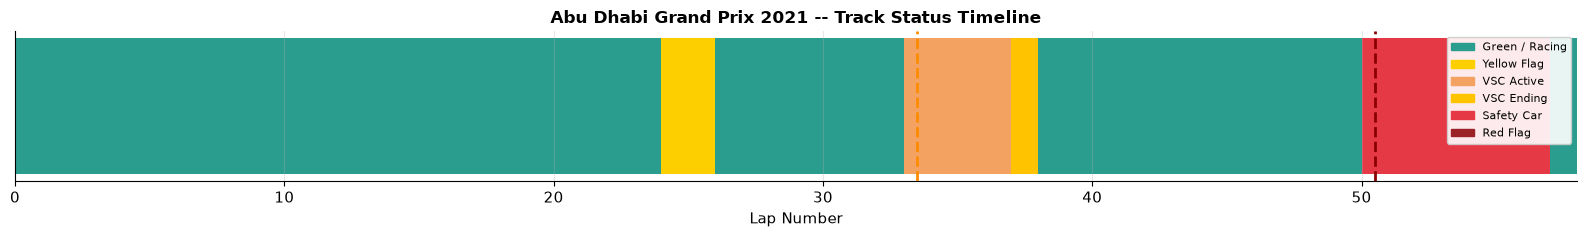

In [22]:
plot_track_status_timeline(abu_tl, 'Abu Dhabi Grand Prix 2021 -- Track Status Timeline')


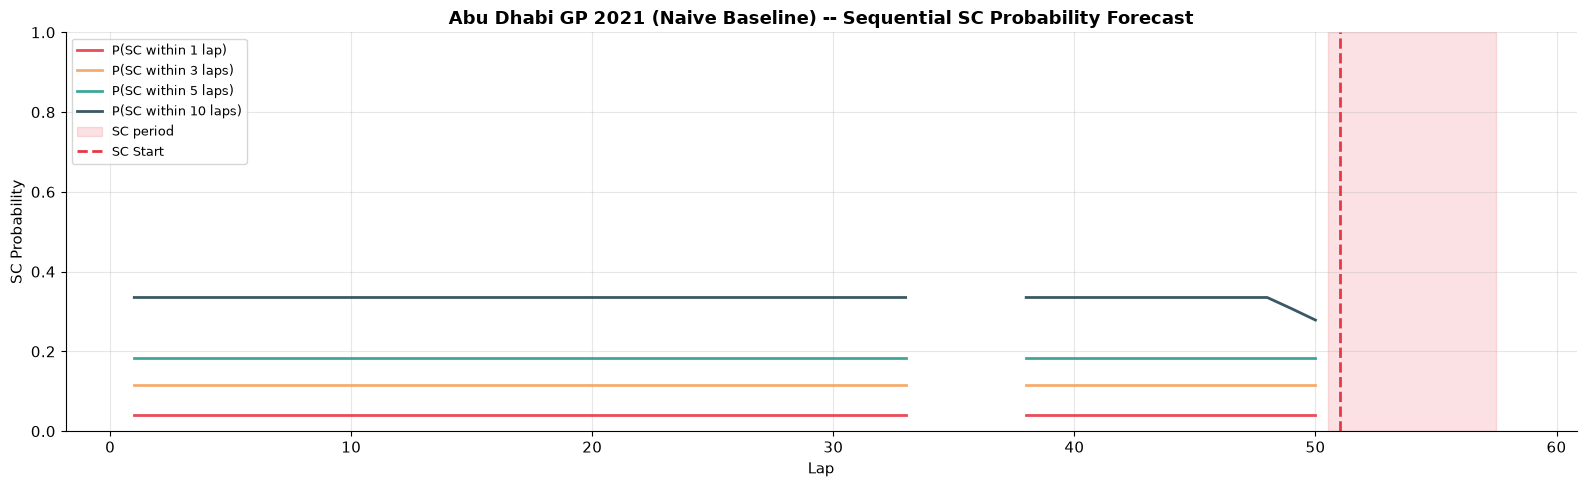

In [23]:
class NaiveBaselineModel:
    # Constant hazard = global SC rate per lap
    def __init__(self, p=0.04): self.p = p
    def predict_proba(self, X):
        n = len(X) if hasattr(X, '__len__') else 1
        return np.column_stack([np.full(n, 1-self.p), np.full(n, self.p)])


naive_dict = {'model': NaiveBaselineModel(0.04), 'scaler': None,
              'features': get_available_features(abu_feat), 'type': 'logistic'}

abu_replay_naive = replay_race(abu_feat, naive_dict, get_available_features(abu_feat), target_type='SC')

plot_probability_forecast(abu_replay_naive, abu_sc_events,
                           race_name='Abu Dhabi GP 2021 (Naive Baseline)', target_type='sc')


In [24]:
def print_race_dashboard(replay_df, lap, race_name=''):
    # Print formatted SC probability dashboard for a specific lap
    row = replay_df[replay_df['prediction_lap'] == lap]
    if len(row) == 0: return
    row = row.iloc[0]
    print(f'\n{"="*55}')
    print(f' F1-SIS SC PROBABILITY FORECAST')
    print(f' {race_name}  |  End of Lap: {lap}')
    active = row['prediction_active']
    print(f' Prediction active: {"YES" if active else "NO (SC/VSC/RF active)"}')
    print(f'{'-'*55}')
    if active:
        for n in HORIZONS:
            p = row.get(f'p_sc_{n}', np.nan)
            print(f'  P(SC within {n:>2} laps) = {p:6.1%}')
        probs = [row.get(f'p_sc_{n}', 0) for n in HORIZONS]
        ok    = all(probs[i] <= probs[i+1] + 1e-6 for i in range(len(probs)-1))
        print(f'  Monotonicity: {"[OK] P1 <= P3 <= P5 <= P10" if ok else "[!] VIOLATION"}')
    print(f'{"="*55}')


# Dashboard around SC event
for lap in [48, 49, 50, 51, 52, 53, 54, 55, 56, 57]:
    print_race_dashboard(abu_replay_naive, lap, 'Abu Dhabi GP 2021')



 F1-SIS SC PROBABILITY FORECAST
 Abu Dhabi GP 2021  |  End of Lap: 48
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  33.5%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 Abu Dhabi GP 2021  |  End of Lap: 49
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  30.7%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 Abu Dhabi GP 2021  |  End of Lap: 50
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  27.9%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 

---

## 22. Italian GP 2021 Validation


ITALIAN GRAND PRIX 2021 -- PIPELINE VALIDATION
Total laps: 53
SC events : 1

SC Events:
                   race_id  sc_event_id  sc_start_lap  sc_end_lap  sc_duration
0  2021_Italian_Grand_Prix            1            25          30            6


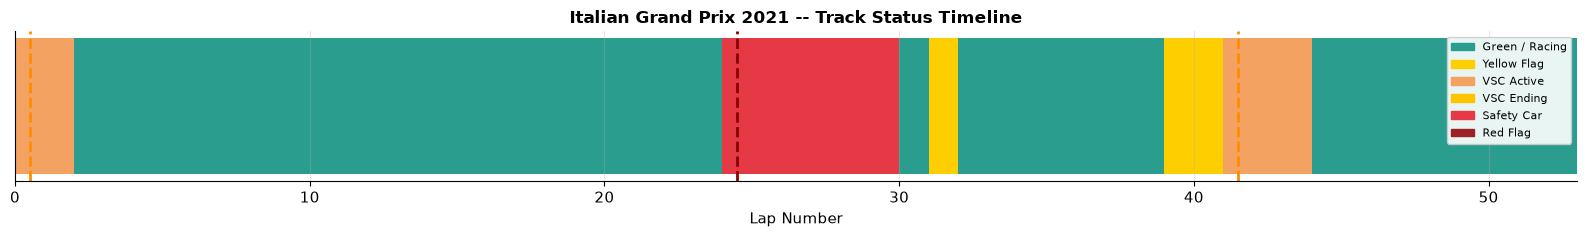

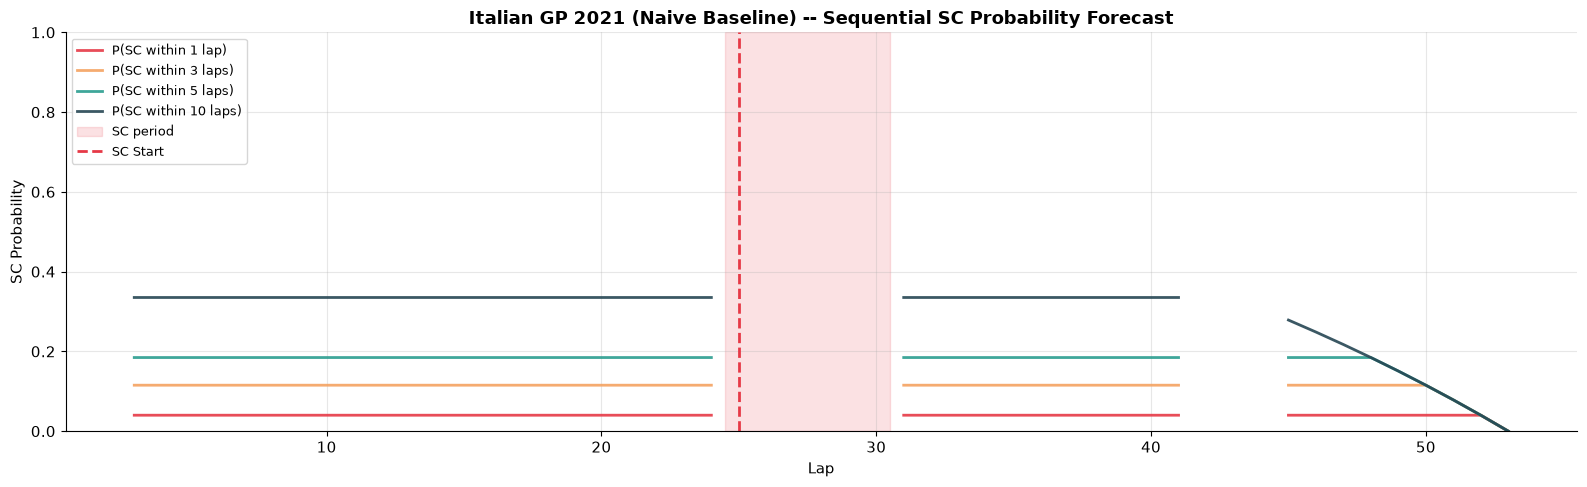


 F1-SIS SC PROBABILITY FORECAST
 Italian GP 2021  |  End of Lap: 22
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  33.5%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 Italian GP 2021  |  End of Lap: 23
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  33.5%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 Italian GP 2021  |  End of Lap: 24
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.0%
  P(SC within  3 laps) =  11.5%
  P(SC within  5 laps) =  18.5%
  P(SC within 10 laps) =  33.5%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 Italia

In [25]:
italian_tl   = build_prediction_targets(italian_tl, italian_sc_events, italian_vsc_events)
italian_feat = build_causal_features(italian_tl)

print('=' * 60)
print('ITALIAN GRAND PRIX 2021 -- PIPELINE VALIDATION')
print('=' * 60)
print(f'Total laps: {int(italian_feat["total_laps"].iloc[0])}')
print(f'SC events : {len(italian_sc_events)}')
print('\nSC Events:')
print(italian_sc_events.to_string())

plot_track_status_timeline(italian_tl, 'Italian Grand Prix 2021 -- Track Status Timeline')

italian_replay = replay_race(italian_feat, naive_dict, get_available_features(italian_feat), target_type='SC')
plot_probability_forecast(italian_replay, italian_sc_events,
                           race_name='Italian GP 2021 (Naive Baseline)', target_type='sc')

for lap in [22, 23, 24, 25, 26, 27, 28, 29, 30]:
    print_race_dashboard(italian_replay, lap, 'Italian GP 2021')


---

## 23. Full Historical Experiment

Load all 172 races (2018--2025), build full pipeline, train ML models, evaluate.

> **Note:** The two validation races above serve as unit tests. This section runs the full experiment with chronological train/val/test splitting.


In [26]:
print('Loading all race data (2018-2025)...')
t0 = time.time()
all_driver_lap_df = load_all_races(DATA_DIR)
print(f'Load time: {time.time() - t0:.1f}s')


Loading all race data (2018-2025)...
Loaded 172 races | 172 unique race IDs | 188,482 rows
Load time: 3.1s


In [27]:
print('Building race-level timelines for all races...')
all_race_ids  = sorted(all_driver_lap_df['race_id'].unique())
all_timelines = {}
failed        = []

for rid in all_race_ids:
    try:
        df   = all_driver_lap_df[all_driver_lap_df['race_id'] == rid].copy()
        tl   = build_race_level_timeline(df)
        tl, sc_ev, vsc_ev = build_event_table(tl)
        tl   = build_prediction_targets(tl, sc_ev, vsc_ev)
        tl   = build_causal_features(tl)
        all_timelines[rid] = tl
    except Exception as e:
        failed.append((rid, str(e)))

print(f'Processed: {len(all_timelines)}/{len(all_race_ids)} races')
if failed:
    for r, e in failed[:5]:
        print(f'  FAILED: {r}: {e}')


Building race-level timelines for all races...
Processed: 172/172 races


In [28]:
train_ids, val_ids, test_ids = chronological_split(list(all_timelines.keys()))


Split summary:
  Training    : 102 races
  Validation  : 22 races
  Test        : 48 races


In [29]:
print('Building historical priors from training races only...')
try:
    historical_priors = build_historical_prior(all_timelines, train_ids)
    print(f'  Global SC prob per lap: {historical_priors["global_sc_prob"]:.4f}')
    print(f'  Training laps         : {historical_priors["valid_laps"]:,}')
    print(f'  Total SC starts       : {historical_priors["total_sc_starts"]}')
    print()
    print('  SC probability by race progress (Heilmeier-style):')
    print(historical_priors['progress_sc_prob'].to_string())
except Exception as e:
    print(f'  Could not build priors: {e}')
    historical_priors = None


Building historical priors from training races only...
  Global SC prob per lap: 0.0000
  Training laps         : 5,471
  Total SC starts       : 0

  SC probability by race progress (Heilmeier-style):
progress_bin
0-10%      0.001157
10-20%     0.000879
20-30%     0.000880
30-40%     0.000853
40-50%     0.000888
50-60%     0.000906
60-70%     0.000899
70-80%     0.000992
80-90%     0.000911
90-100%    0.000831


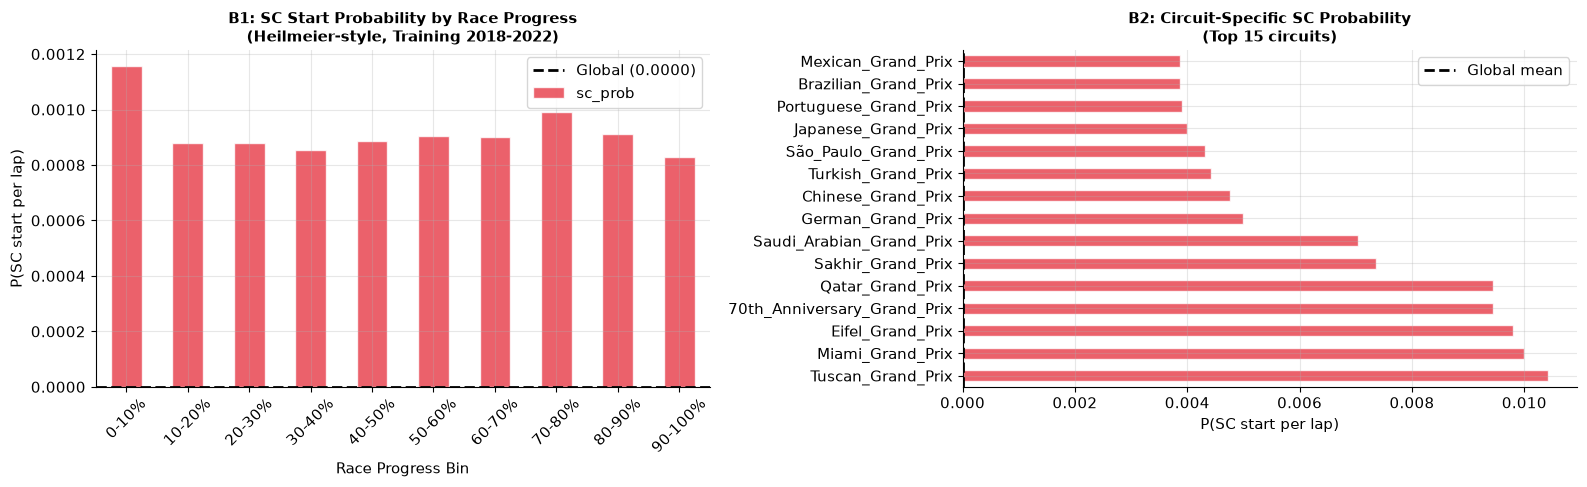

In [30]:
# Visualise Heilmeier-style baseline
if historical_priors is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    prog_probs = historical_priors['progress_sc_prob']
    prog_probs.plot(kind='bar', ax=axes[0], color=PALETTE['sc'], alpha=0.8, edgecolor='white')
    axes[0].axhline(historical_priors['global_sc_prob'], color='black', linestyle='--',
                    linewidth=2, label=f'Global ({historical_priors["global_sc_prob"]:.4f})')
    axes[0].set_title('B1: SC Start Probability by Race Progress\n(Heilmeier-style, Training 2018-2022)',
                       fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Race Progress Bin'); axes[0].set_ylabel('P(SC start per lap)')
    axes[0].tick_params(axis='x', rotation=45); axes[0].legend()

    circ_probs = pd.Series(historical_priors['circuit_sc_prob']).sort_values(ascending=False).head(15)
    circ_probs.plot(kind='barh', ax=axes[1], color=PALETTE['sc'], alpha=0.8, edgecolor='white')
    axes[1].axvline(historical_priors['global_sc_prob'], color='black', linestyle='--', linewidth=2, label='Global mean')
    axes[1].set_title('B2: Circuit-Specific SC Probability\n(Top 15 circuits)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('P(SC start per lap)'); axes[1].legend()
    plt.tight_layout(); plt.show()


=== Class Imbalance Analysis (Training Set) ===
Valid prediction laps: 5,471
  SC_next_ 1:    50 /   5375 = 0.93% | imbalance ~1:107
  SC_next_ 3:   151 /   5186 = 2.91% | imbalance ~1:34
  SC_next_ 5:   243 /   5007 = 4.85% | imbalance ~1:20
  SC_next_10:   426 /   4544 = 9.38% | imbalance ~1:10


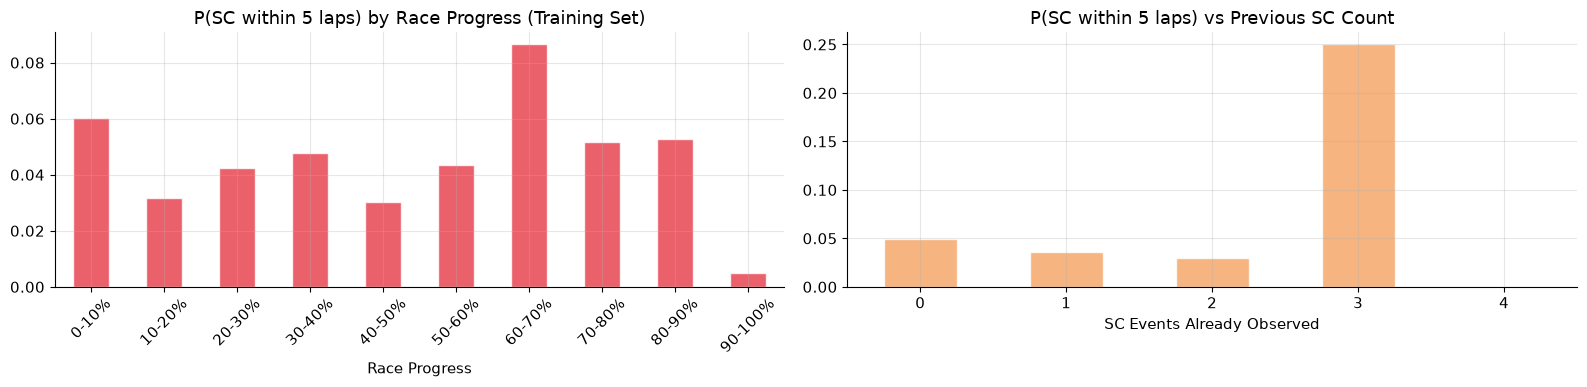

In [31]:
# Rebuild timelines with historical priors
all_timelines_p = {}
for rid, tl in all_timelines.items():
    all_timelines_p[rid] = build_causal_features(tl, historical_priors=historical_priors)

analyze_class_imbalance(all_timelines_p, train_ids)


In [32]:
HORIZON_TRAIN = 5   # Train/evaluate at 5-lap horizon for demonstration
TARGET_TRAIN  = 'SC'

avail_feat_cols = get_available_features(list(all_timelines_p.values())[0])
print(f'Available feature columns: {len(avail_feat_cols)}')

X_train, y_train, w_train = create_sequential_samples(
    all_timelines_p, train_ids, avail_feat_cols, HORIZON_TRAIN, TARGET_TRAIN
)
X_val, y_val, w_val = create_sequential_samples(
    all_timelines_p, val_ids, avail_feat_cols, HORIZON_TRAIN, TARGET_TRAIN
)
X_test, y_test, w_test = create_sequential_samples(
    all_timelines_p, test_ids, avail_feat_cols, HORIZON_TRAIN, TARGET_TRAIN
)

print(f'Training   : {len(X_train):,} (pos={y_train.mean():.2%})')
print(f'Validation : {len(X_val):,} (pos={y_val.mean():.2%})')
print(f'Test       : {len(X_test):,} (pos={y_test.mean():.2%})')


Available feature columns: 34
Training   : 5,007 (pos=4.85%)
Validation : 1,130 (pos=4.87%)
Test       : 2,444 (pos=3.76%)


In [33]:
# MODEL 1: Logistic
print('\nTraining M1: Logistic Hazard Model...')
logistic_dict   = train_hazard_model(X_train, y_train, w_train)
log_probs_val   = predict_proba_from_dict(logistic_dict, X_val)
log_metrics     = evaluate_probabilities(y_val.values, log_probs_val, 'Logistic (uncal)', HORIZON_TRAIN)
print('Calibrating logistic...')
logistic_cal    = calibrate_probabilities(logistic_dict, X_val, y_val)
log_probs_cal   = apply_calibration(logistic_cal, log_probs_val)
log_metrics_c   = evaluate_probabilities(y_val.values, log_probs_cal, 'Logistic (isotonic)', HORIZON_TRAIN)



Training M1: Logistic Hazard Model...
Logistic model | features: 34 | pos rate: 4.85%
  [Logistic (uncal)] h=5 | Brier=0.2394 | LogLoss=0.6821 | ROC-AUC=0.484 | PR-AUC=0.052 | ECE=0.4493
Calibrating logistic...
Calibration (isotonic): raw_mean=0.425 -> cal_mean=0.049 | pos_rate=0.049
  [Logistic (isotonic)] h=5 | Brier=0.0460 | LogLoss=0.1903 | ROC-AUC=0.587 | PR-AUC=0.061 | ECE=0.0000


In [34]:
# MODEL 2a: XGBoost
if XGBOOST_AVAILABLE:
    print('\nTraining M2a: XGBoost...')
    xgb_dict      = train_tree_model(X_train, y_train, w_train, use_catboost=False)
    xgb_probs_val = predict_proba_from_dict(xgb_dict, X_val)
    xgb_metrics   = evaluate_probabilities(y_val.values, xgb_probs_val, 'XGBoost (uncal)', HORIZON_TRAIN)
    xgb_cal       = calibrate_probabilities(xgb_dict, X_val, y_val)
    xgb_probs_cal = apply_calibration(xgb_cal, xgb_probs_val)
    xgb_metrics_c = evaluate_probabilities(y_val.values, xgb_probs_cal, 'XGBoost (isotonic)', HORIZON_TRAIN)



Training M2a: XGBoost...
xgboost | features: 34 | pos_weight: 19.6 | pos rate: 4.85%
  [XGBoost (uncal)] h=5 | Brier=0.1275 | LogLoss=0.5395 | ROC-AUC=0.438 | PR-AUC=0.044 | ECE=0.4530
Calibration (isotonic): raw_mean=0.154 -> cal_mean=0.049 | pos_rate=0.049
  [XGBoost (isotonic)] h=5 | Brier=0.0463 | LogLoss=0.1941 | ROC-AUC=0.543 | PR-AUC=0.054 | ECE=0.0000


In [35]:
# MODEL 2b: CatBoost
if CATBOOST_AVAILABLE:
    print('\nTraining M2b: CatBoost...')
    cat_dict      = train_tree_model(X_train, y_train, w_train, use_catboost=True)
    cat_probs_val = predict_proba_from_dict(cat_dict, X_val)
    cat_metrics   = evaluate_probabilities(y_val.values, cat_probs_val, 'CatBoost (uncal)', HORIZON_TRAIN)
    cat_cal       = calibrate_probabilities(cat_dict, X_val, y_val)
    cat_probs_cal = apply_calibration(cat_cal, cat_probs_val)
    cat_metrics_c = evaluate_probabilities(y_val.values, cat_probs_cal, 'CatBoost (isotonic)', HORIZON_TRAIN)



Training M2b: CatBoost...
catboost | features: 34 | pos_weight: 19.6 | pos rate: 4.85%
  [CatBoost (uncal)] h=5 | Brier=0.4336 | LogLoss=1.2530 | ROC-AUC=0.442 | PR-AUC=0.051 | ECE=0.4635
Calibration (isotonic): raw_mean=0.565 -> cal_mean=0.049 | pos_rate=0.049
  [CatBoost (isotonic)] h=5 | Brier=0.0461 | LogLoss=0.1929 | ROC-AUC=0.558 | PR-AUC=0.057 | ECE=0.0000


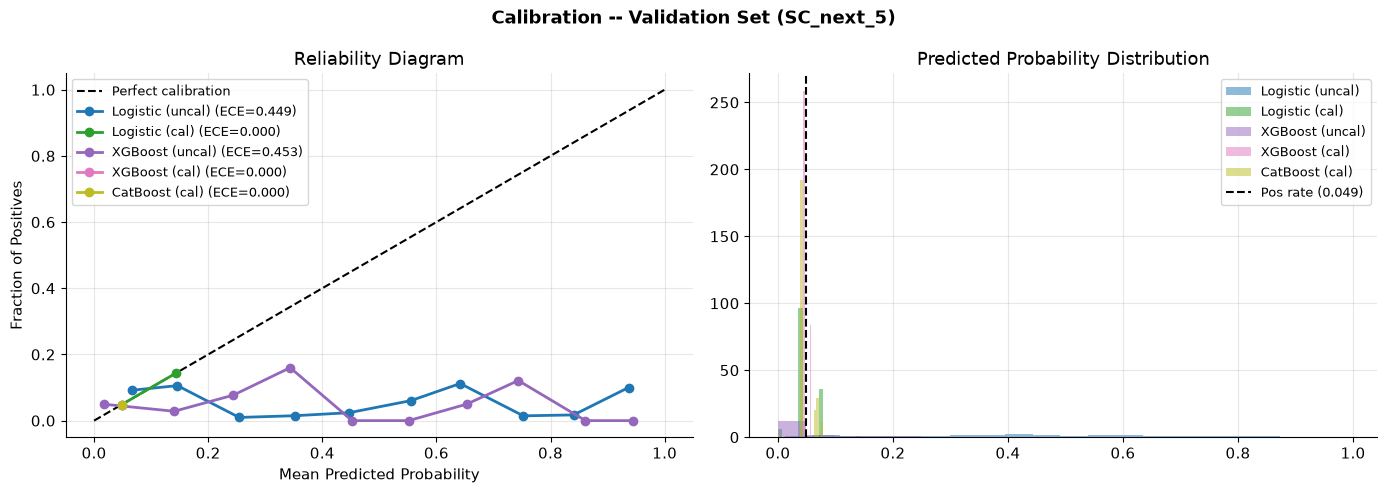

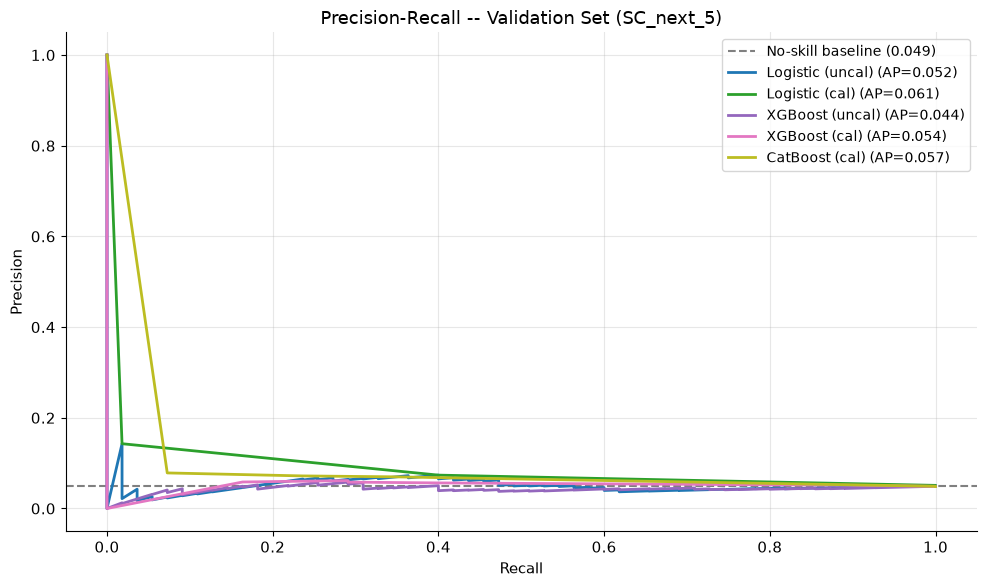

In [36]:
# Calibration plots
prob_dicts_val = {
    'Logistic (uncal)': log_probs_val,
    'Logistic (cal)':   log_probs_cal,
}
if XGBOOST_AVAILABLE:
    prob_dicts_val['XGBoost (uncal)'] = xgb_probs_val
    prob_dicts_val['XGBoost (cal)']   = xgb_probs_cal
if CATBOOST_AVAILABLE:
    prob_dicts_val['CatBoost (cal)']  = cat_probs_cal

plot_calibration(y_val.values, prob_dicts_val,
                 title=f'Calibration -- Validation Set (SC_next_{HORIZON_TRAIN})')
plot_pr_curve(y_val.values, prob_dicts_val,
              title=f'Precision-Recall -- Validation Set (SC_next_{HORIZON_TRAIN})')


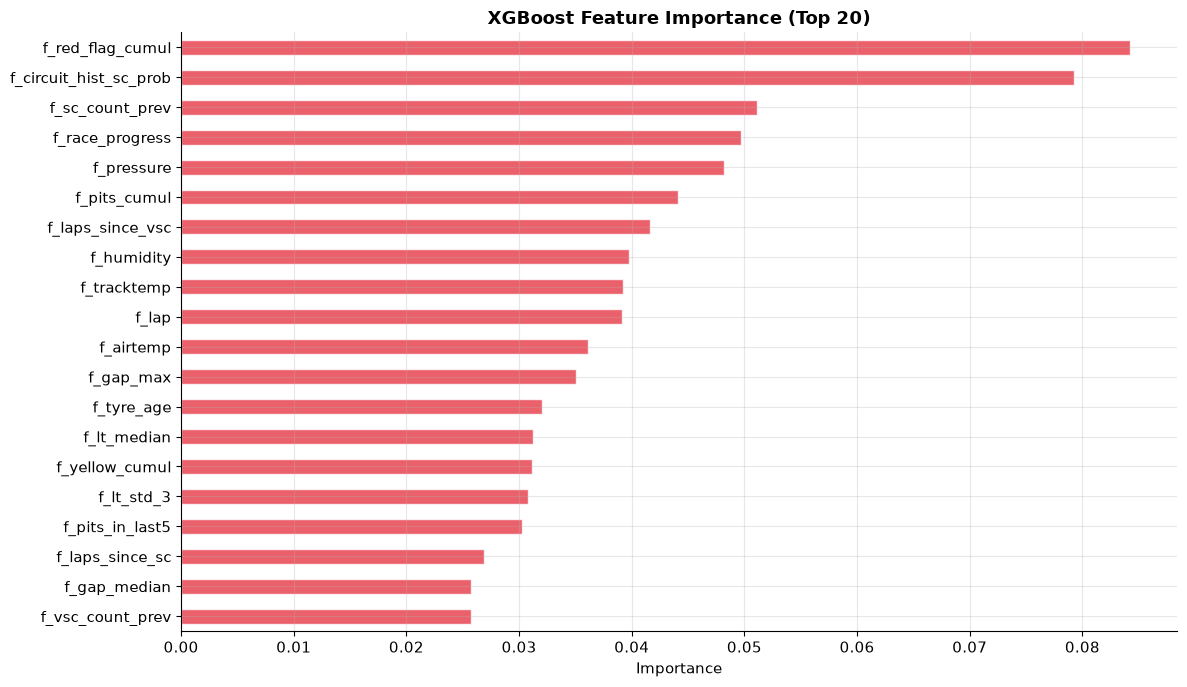

In [37]:
# XGBoost Feature Importance
if XGBOOST_AVAILABLE:
    feat_imp = pd.Series(
        xgb_dict['model'].feature_importances_, index=avail_feat_cols
    ).sort_values(ascending=True).tail(20)
    fig, ax = plt.subplots(figsize=(12, 7))
    feat_imp.plot(kind='barh', ax=ax, color=PALETTE['sc'], alpha=0.8, edgecolor='white')
    ax.set_title('XGBoost Feature Importance (Top 20)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()


In [38]:
# Multi-horizon evaluation (XGBoost, Test Set)
if XGBOOST_AVAILABLE:
    print('\n=== Multi-Horizon Evaluation (XGBoost, Test Set) ===')
    all_h_metrics = []
    for n in HORIZONS:
        try:
            X_tr_n, y_tr_n, w_tr_n = create_sequential_samples(all_timelines_p, train_ids, avail_feat_cols, n, 'SC')
            X_v_n,  y_v_n, _       = create_sequential_samples(all_timelines_p, val_ids,   avail_feat_cols, n, 'SC')
            X_t_n,  y_t_n, _       = create_sequential_samples(all_timelines_p, test_ids,  avail_feat_cols, n, 'SC')
            m_n   = train_tree_model(X_tr_n, y_tr_n, w_tr_n)
            m_n_c = calibrate_probabilities(m_n, X_v_n, y_v_n)
            p_t_n = apply_calibration(m_n_c, predict_proba_from_dict(m_n_c, X_t_n))
            m     = evaluate_probabilities(y_t_n.values, p_t_n, f'XGB h={n}', n)
            all_h_metrics.append(m)
        except Exception as e:
            print(f'  Horizon {n}: {e}')
    if all_h_metrics:
        mdf = pd.DataFrame([m for m in all_h_metrics if m])
        print()
        print(mdf[['horizon','brier_score','log_loss','roc_auc','pr_auc','ece']].to_string(index=False))



=== Multi-Horizon Evaluation (XGBoost, Test Set) ===
xgboost | features: 34 | pos_weight: 106.5 | pos rate: 0.93%
Calibration (isotonic): raw_mean=0.041 -> cal_mean=0.009 | pos_rate=0.009
  [XGB h=1] h=1 | Brier=0.0072 | LogLoss=0.0431 | ROC-AUC=0.547 | PR-AUC=0.008 | ECE=0.0017
xgboost | features: 34 | pos_weight: 33.3 | pos rate: 2.91%
Calibration (isotonic): raw_mean=0.128 -> cal_mean=0.030 | pos_rate=0.030
  [XGB h=3] h=3 | Brier=0.0217 | LogLoss=0.1072 | ROC-AUC=0.483 | PR-AUC=0.023 | ECE=0.0074
xgboost | features: 34 | pos_weight: 19.6 | pos rate: 4.85%
Calibration (isotonic): raw_mean=0.154 -> cal_mean=0.049 | pos_rate=0.049
  [XGB h=5] h=5 | Brier=0.0362 | LogLoss=0.1605 | ROC-AUC=0.566 | PR-AUC=0.048 | ECE=0.0108
xgboost | features: 34 | pos_weight: 9.7 | pos rate: 9.38%
Calibration (isotonic): raw_mean=0.195 -> cal_mean=0.101 | pos_rate=0.101
  [XGB h=10] h=10 | Brier=0.0651 | LogLoss=0.2556 | ROC-AUC=0.524 | PR-AUC=0.084 | ECE=0.0599

 horizon  brier_score  log_loss  roc_au

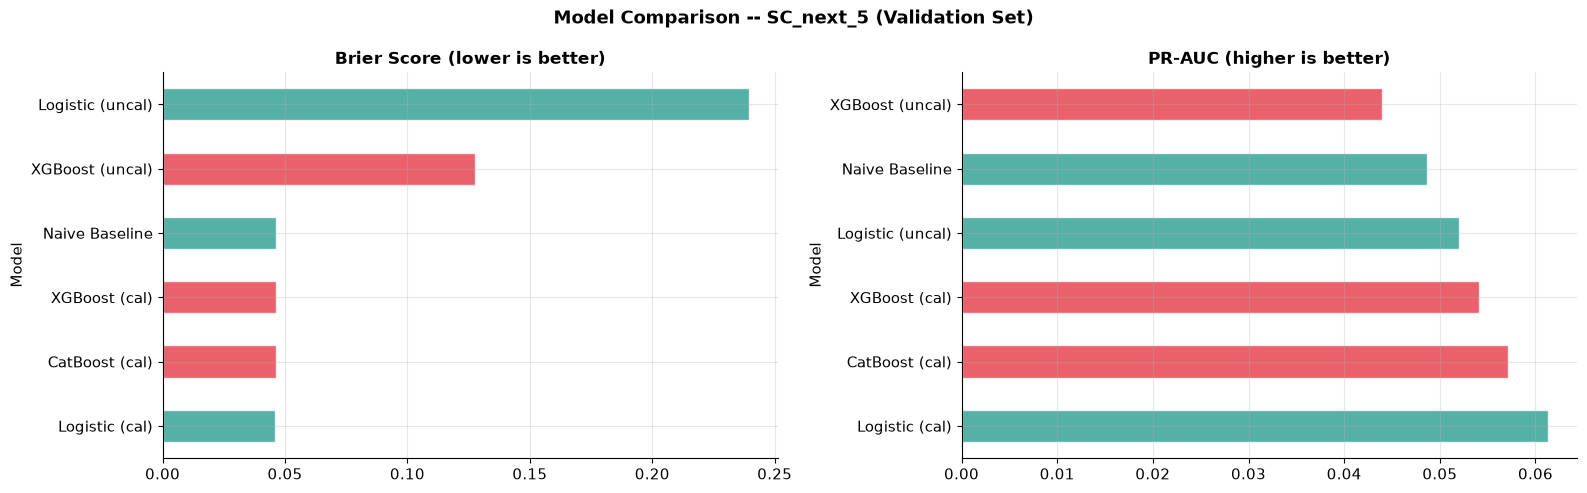


Brier Score ranking:
           Model    Brier
  Logistic (cal) 0.045974
  CatBoost (cal) 0.046147
   XGBoost (cal) 0.046267
  Naive Baseline 0.046304
 XGBoost (uncal) 0.127475
Logistic (uncal) 0.239392


In [39]:
# Brier score comparison chart
try:
    models_eval = [
        ('Naive Baseline',    np.full(len(y_val), y_train.mean())),
        ('Logistic (uncal)',  log_probs_val),
        ('Logistic (cal)',    log_probs_cal),
    ]
    if XGBOOST_AVAILABLE:
        models_eval += [('XGBoost (uncal)', xgb_probs_val), ('XGBoost (cal)', xgb_probs_cal)]
    if CATBOOST_AVAILABLE:
        models_eval += [('CatBoost (cal)', cat_probs_cal)]

    brier_data = [(n, brier_score_loss(y_val.values, p)) for n, p in models_eval]
    pr_data    = [(n, average_precision_score(y_val.values, p)) for n, p in models_eval]
    brier_df   = pd.DataFrame(brier_data, columns=['Model', 'Brier']).sort_values('Brier')
    pr_df      = pd.DataFrame(pr_data,    columns=['Model', 'PR-AUC']).sort_values('PR-AUC', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors_b = [PALETTE['sc'] if 'XGB' in m or 'Cat' in m else PALETTE['normal'] for m in brier_df['Model']]
    brier_df.plot(kind='barh', x='Model', y='Brier', ax=axes[0], color=colors_b, alpha=0.8, edgecolor='white', legend=False)
    axes[0].set_title('Brier Score (lower is better)', fontsize=12, fontweight='bold')

    colors_p = [PALETTE['sc'] if 'XGB' in m or 'Cat' in m else PALETTE['normal'] for m in pr_df['Model']]
    pr_df.plot(kind='barh', x='Model', y='PR-AUC', ax=axes[1], color=colors_p, alpha=0.8, edgecolor='white', legend=False)
    axes[1].set_title('PR-AUC (higher is better)', fontsize=12, fontweight='bold')

    plt.suptitle(f'Model Comparison -- SC_next_{HORIZON_TRAIN} (Validation Set)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print('\nBrier Score ranking:')
    print(brier_df.to_string(index=False))
except Exception as e:
    print(f'Model comparison: {e}')


Full replay on test race: 2024_Canadian_Grand_Prix


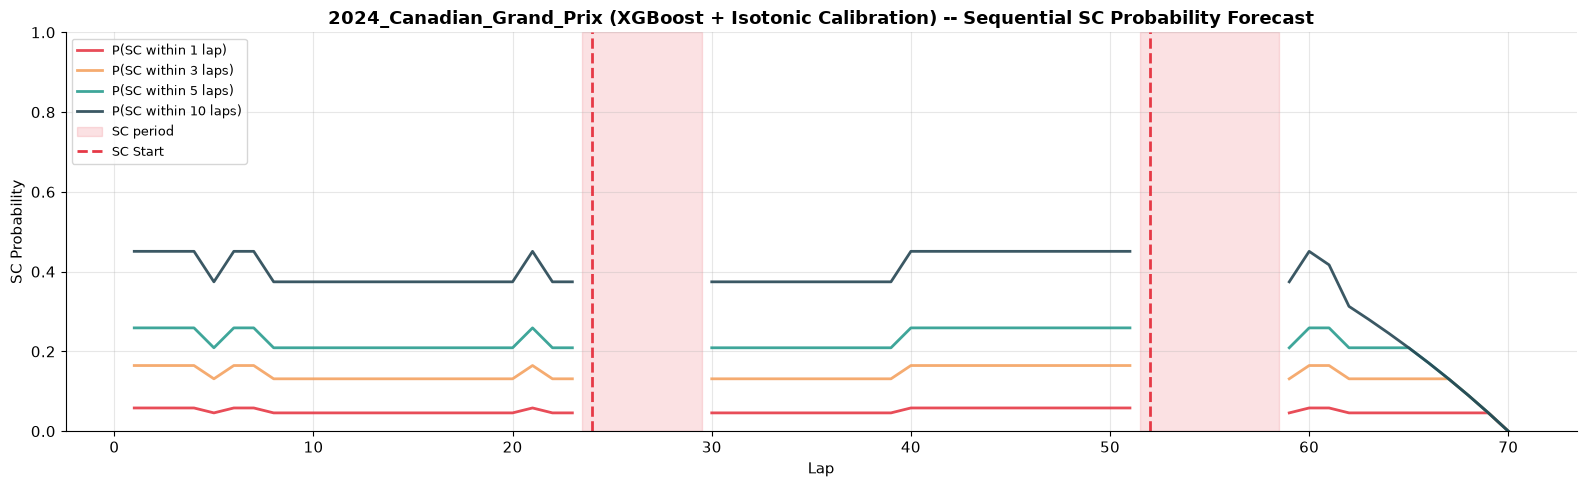


Dashboard around SC event at lap 24:

 F1-SIS SC PROBABILITY FORECAST
 2024_Canadian_Grand_Prix  |  End of Lap: 20
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.6%
  P(SC within  3 laps) =  13.1%
  P(SC within  5 laps) =  20.9%
  P(SC within 10 laps) =  37.4%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 2024_Canadian_Grand_Prix  |  End of Lap: 21
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   5.8%
  P(SC within  3 laps) =  16.5%
  P(SC within  5 laps) =  25.9%
  P(SC within 10 laps) =  45.1%
  Monotonicity: [OK] P1 <= P3 <= P5 <= P10

 F1-SIS SC PROBABILITY FORECAST
 2024_Canadian_Grand_Prix  |  End of Lap: 22
 Prediction active: YES
-------------------------------------------------------
  P(SC within  1 laps) =   4.6%
  P(SC within  3 laps) =  13.1%
  P(SC within  5 laps) =  20.9%
  P(SC within 10 laps) =  37.4%
  Monotonicity: [O

In [40]:
# Full replay on a test race with XGBoost
if XGBOOST_AVAILABLE and len(test_ids) > 0:
    # Find a test race with SC event
    test_race = None
    for rid in test_ids:
        tl_t = all_timelines_p.get(rid)
        if tl_t is not None and 'sc_start' in tl_t.columns and tl_t['sc_start'].any():
            test_race = rid; break
    if test_race is None:
        test_race = test_ids[0]

    print(f'Full replay on test race: {test_race}')
    tl_test = all_timelines_p[test_race]
    _, sc_ev_test, _ = build_event_table(tl_test)

    xgb_replay = replay_race(tl_test, xgb_cal, avail_feat_cols,
                              historical_priors=historical_priors, target_type='SC')
    plot_probability_forecast(xgb_replay, sc_ev_test,
                               race_name=f'{test_race} (XGBoost + Isotonic Calibration)',
                               target_type='sc')
    if len(sc_ev_test) > 0:
        sc_start = int(sc_ev_test['sc_start_lap'].iloc[0])
        print(f'\nDashboard around SC event at lap {sc_start}:')
        for lap in range(max(1, sc_start - 4), sc_start + 3):
            print_race_dashboard(xgb_replay, lap, test_race)


---

## 24. Monte Carlo Integration Interface

Demonstrates how SC probability outputs feed the Monte Carlo strategy simulator.

> **Literature basis (Heilmeier et al.):** Embeds SC probabilities into a Monte Carlo loop. Our F1-SIS contribution: adaptive probabilities that update every lap as $H_t$ evolves.

### Architecture

```
End of lap t:
    RaceState_t -> SC/VSC Model -> {P_1, P_3, P_5, P_10}
                                          |
                                          v
    Monte Carlo: for each scenario i:
        u ~ Uniform(0,1)
        for each future lap k:
            if u < h(t+k): SC starts at t+k; break
    Simulate race under each scenario
                                          |
                                          v
    Strategy Engine evaluates across N scenarios
```



=== SC Probability Interface Output (Lap 48 of 58) ===
  Prediction active: True
  P(SC within  1 laps) =   4.6%
  P(SC within  3 laps) =  13.1%
  P(SC within  5 laps) =  20.9%
  P(SC within 10 laps) =  37.4%

=== Monte Carlo (5,000 scenarios) ===
  SC scenarios  : 1877 / 5000 = 37.5%
  Median SC lap : 53


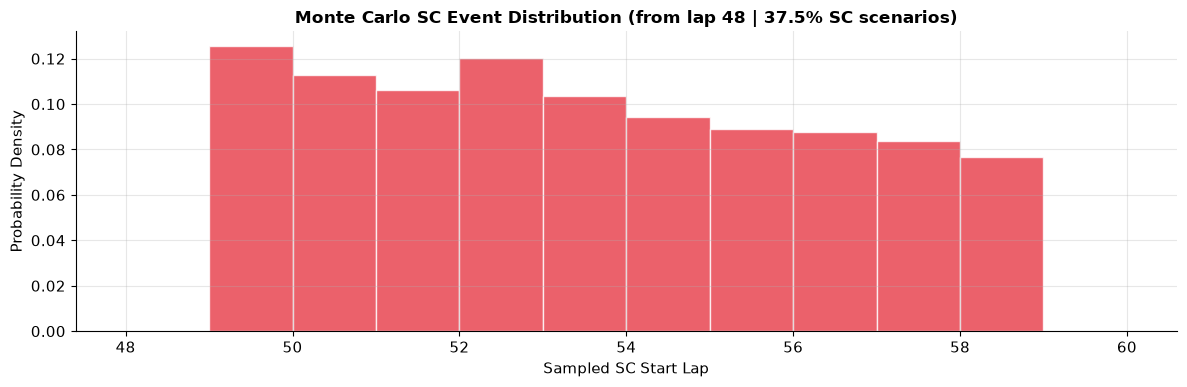

In [41]:
def sc_probability_interface(race_state_t, model_dict, feature_cols, horizons=HORIZONS):
    # PRODUCTION INTERFACE: SC/VSC Probability Model
    # This is the entry point for the Monte Carlo strategy simulator.
    # In production: race_state_t = RaceState_t from Race State Manager.
    # Currently (provisional): dict of features from CSV data.
    if race_state_t.get('sc_active', False) or race_state_t.get('vsc_active', False):
        return {'prediction_active': False, 'reason': 'SC or VSC currently active',
                **{f'p_sc_{n}': np.nan for n in horizons},
                'hazard_sequence': [np.nan] * max(horizons)}

    X     = pd.DataFrame([race_state_t])
    avail = [c for c in feature_cols if c in X.columns]
    raw   = predict_proba_from_dict(model_dict, X[avail].fillna(0))
    h_b   = float(raw[0])
    if 'calibrator' in model_dict:
        h_b = float(apply_calibration(model_dict, np.array([h_b]))[0])

    cur_lap  = int(race_state_t.get('f_lap', 1))
    tot_laps = int(race_state_t.get('total_laps', 58))
    max_h    = max(horizons)
    hazards  = [h_b if cur_lap + k <= tot_laps else 0.0 for k in range(1, max_h + 1)]
    h_probs  = calculate_horizon_probabilities(np.array(hazards), horizons)
    return {'prediction_active': True, 'hazard_sequence': hazards,
            **{f'p_sc_{n}': h_probs[n] for n in horizons}}


def monte_carlo_sc_sampling(sc_probs, current_lap, total_laps, n_simulations=5000, seed=RANDOM_SEED):
    # Sample future SC event laps from hazard sequence.
    # Follows Heilmeier et al. philosophy: per-lap Bernoulli trials.
    rng     = np.random.default_rng(seed)
    hazards = np.array(sc_probs.get('hazard_sequence', [0.05] * 10))
    sc_laps = []
    for _ in range(n_simulations):
        sc_lap = np.nan
        for k, h in enumerate(hazards, start=1):
            future_lap = current_lap + k
            if future_lap > total_laps: break
            if rng.uniform() < h: sc_lap = float(future_lap); break
        sc_laps.append(sc_lap)
    return np.array(sc_laps)


# Demo at lap 48 of Abu Dhabi 2021
example_state = {
    'f_lap': 48, 'f_race_progress': 0.83, 'f_laps_remaining': 10,
    'f_progress_sq': 0.83**2, 'f_retirements_cumul': 2, 'f_yellow_cumul': 8,
    'f_red_flag_cumul': 0, 'f_pits_in_last5': 5, 'f_pits_cumul': 32,
    'f_sc_count_prev': 0, 'f_vsc_count_prev': 1,
    'f_laps_since_sc': 999, 'f_laps_since_vsc': 12,
    'f_any_sc_prev': 0, 'f_any_vsc_prev': 1,
    'f_n_cars': 18, 'f_gap_median': 2.5, 'f_gap_max': 45.0, 'f_gap_delta': -0.3,
    'f_lt_median': 100.5, 'f_lt_std_3': 1.2, 'f_lt_std_5': 1.5,
    'f_lt_anomaly': -0.5, 'f_lt_within_field_std': 2.1,
    'f_tyre_age': 22.0, 'f_airtemp': 24.6, 'f_tracktemp': 28.4,
    'f_humidity': 58.0, 'f_pressure': 1017.6, 'f_windspeed': 0.4,
    'f_rainfall': 0, 'f_airtemp_trend': 0.0,
    'f_circuit_hist_sc_prob': 0.035, 'f_progress_hist_sc_prob': 0.04,
    'sc_active': False, 'vsc_active': False, 'total_laps': 58,
}

if XGBOOST_AVAILABLE:
    sc_forecast = sc_probability_interface(example_state, xgb_cal, avail_feat_cols)
else:
    sc_forecast = sc_probability_interface(example_state, naive_dict, get_available_features(abu_feat))

print('\n=== SC Probability Interface Output (Lap 48 of 58) ===')
print(f'  Prediction active: {sc_forecast["prediction_active"]}')
for n in HORIZONS:
    print(f'  P(SC within {n:>2} laps) = {sc_forecast[f"p_sc_{n}"]:6.1%}')

sc_samples  = monte_carlo_sc_sampling(sc_forecast, current_lap=48, total_laps=58, n_simulations=5000)
sc_occurred = ~np.isnan(sc_samples)
print(f'\n=== Monte Carlo (5,000 scenarios) ===')
print(f'  SC scenarios  : {sc_occurred.sum()} / 5000 = {sc_occurred.mean():.1%}')
if sc_occurred.any():
    print(f'  Median SC lap : {int(np.nanmedian(sc_samples[sc_occurred]))}')

fig, ax = plt.subplots(figsize=(12, 4))
sc_clean = sc_samples[sc_occurred]
if len(sc_clean) > 0:
    ax.hist(sc_clean, bins=range(48, 61), color=PALETTE['sc'], alpha=0.8, edgecolor='white', density=True)
ax.set_xlabel('Sampled SC Start Lap'); ax.set_ylabel('Probability Density')
ax.set_title(f'Monte Carlo SC Event Distribution (from lap 48 | {sc_occurred.mean():.1%} SC scenarios)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---

## 25. Race State Manager Interface Placeholder

> **DO NOT permanently implement Race State Manager logic here.**  
> The Race State Manager is a separate F1-SIS component.

This placeholder documents:
1. The interface contract this notebook expects to receive
2. Where the temporary CSV-based adapter will be replaced
3. What `RaceState_t` must contain for the SC/VSC model to operate


In [42]:
class RaceStateManagerInterface:
    # PLACEHOLDER -- Race State Manager Interface Contract
    # ====================================================
    # Documents the data contract between the Race State Manager
    # and the SC/VSC Probability Model.
    #
    # In production:
    #   Race State Manager -> RaceState_t -> sc_probability_interface()
    #
    # Currently: CSV-based adapter (provisional)
    #
    # RaceState_t expected schema:
    # ============================
    # A. Race Progression
    #    current_lap        : int
    #    total_laps         : int
    #    race_progress      : float [0, 1]
    #    laps_remaining     : int
    # B. Incident History (cumulative up to current lap)
    #    retirements_cumul  : int
    #    yellow_flag_cumul  : int
    # C. SC/VSC History
    #    sc_active          : bool
    #    vsc_active         : bool
    #    sc_count_prev      : int
    #    vsc_count_prev     : int
    #    laps_since_sc      : int  (999 = no previous SC)
    #    laps_since_vsc     : int
    # D. Field State
    #    n_cars_running     : int
    #    gap_median_sec     : float
    #    gap_max_sec        : float
    # E. Pace
    #    lap_time_median    : float
    #    lap_time_std       : float
    # F. Tyre
    #    tyre_age_median    : float
    # G. Weather
    #    air_temp           : float
    #    track_temp         : float
    #    humidity           : float
    #    rainfall           : bool
    # H. Circuit
    #    circuit_name       : str

    REQUIRED_FIELDS = [
        'current_lap', 'total_laps', 'race_progress', 'laps_remaining',
        'retirements_cumul', 'yellow_flag_cumul',
        'sc_active', 'vsc_active', 'sc_count_prev', 'vsc_count_prev',
        'laps_since_sc', 'laps_since_vsc',
        'n_cars_running', 'gap_median_sec', 'gap_max_sec',
        'lap_time_median', 'lap_time_std', 'tyre_age_median',
        'air_temp', 'track_temp', 'humidity', 'rainfall', 'circuit_name',
    ]

    @classmethod
    def validate_state(cls, race_state):
        missing = [f for f in cls.REQUIRED_FIELDS if f not in race_state]
        if missing:
            raise ValueError(f'RaceState_t missing required fields: {missing}')
        return True

    @classmethod
    def from_csv_row(cls, row):
        # PROVISIONAL adapter: Convert CSV timeline row to RaceState_t dict.
        # This method will be removed when the Race State Manager is integrated.
        return {
            'current_lap':     int(row.get('lap', 1)),
            'total_laps':      int(row.get('total_laps', 58)),
            'race_progress':   float(row.get('race_progress', 0)),
            'laps_remaining':  int(row.get('f_laps_remaining', 0)),
            'retirements_cumul': int(row.get('retirements_cumulative', 0)),
            'yellow_flag_cumul': int(row.get('f_yellow_cumul', 0)),
            'sc_active':       bool(row.get('sc_active', False)),
            'vsc_active':      bool(row.get('vsc_active', False)),
            'sc_count_prev':   int(row.get('f_sc_count_prev', 0)),
            'vsc_count_prev':  int(row.get('f_vsc_count_prev', 0)),
            'laps_since_sc':   int(row.get('f_laps_since_sc', 999)),
            'laps_since_vsc':  int(row.get('f_laps_since_vsc', 999)),
            'n_cars_running':  int(row.get('n_cars', 20)),
            'gap_median_sec':  float(row.get('gap_median', 0) or 0),
            'gap_max_sec':     float(row.get('gap_max', 0) or 0),
            'lap_time_median': float(row.get('lap_time_median', 90) or 90),
            'lap_time_std':    float(row.get('lap_time_std', 1) or 1),
            'tyre_age_median': float(row.get('tyre_age_median', 10) or 10),
            'air_temp':        float(row.get('AirTemp', 25) or 25),
            'track_temp':      float(row.get('TrackTemp', 30) or 30),
            'humidity':        float(row.get('Humidity', 60) or 60),
            'rainfall':        bool(row.get('Rainfall', False)),
            'circuit_name':    str(row.get('race_id', 'Unknown')),
        }


print('Race State Manager interface placeholder defined.')
print()
print('Integration checklist:')
print('  [ ] Race State Manager provides RaceState_t per lap')
print('  [ ] Remove provisional build_race_level_timeline()')
print('  [ ] Remove provisional build_causal_features()')
print('  [ ] sc_probability_interface() remains unchanged')
print('  [ ] monte_carlo_sc_sampling() remains unchanged')


Race State Manager interface placeholder defined.

Integration checklist:
  [ ] Race State Manager provides RaceState_t per lap
  [ ] Remove provisional build_race_level_timeline()
  [ ] Remove provisional build_causal_features()
  [ ] sc_probability_interface() remains unchanged
  [ ] monte_carlo_sc_sampling() remains unchanged


---

## 26. Limitations

### Data Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| TrackStatus encoding varies across seasons | Possible decoding errors | Validated vs FastF1 columns |
| Driver-lap aggregation is approximate | Race-level state imprecise | Race State Manager will improve |
| Missing weather in some laps | Feature imputation | Median imputation per race |
| Belgian GP 2021 very short (red flag) | Anomalous data | Retained, edge-case handled |
| 172 races total | Modest for deep learning | Transfer learning option |

### Model Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| Constant hazard projection | Future hazards assumed = current | GRU learns dynamic sequences |
| XGBoost treats laps as i.i.d. | Ignores within-race dependencies | GRU model addresses this |
| No driver/telemetry features | Misses overtake attempts, battles | Race State Manager to aggregate |
| Right-censoring by exclusion | Small-sample bias near race ends | Cox PH model would handle properly |

### Evaluation Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| SC events rare (~5-15 per season) | Few positive examples | Class weighting, focal loss, PR-AUC |
| Calibration on validation set only | May not transfer to test | Cross-validate across seasons |


---

## 27. Conclusions

### What This Module Achieves

1. **Principled probabilistic formulation:** The multi-horizon hazard model guarantees monotonicity ($P_1 \leq P_3 \leq P_5 \leq P_{10}$) and calibrated probabilities.

2. **Robust TrackStatus decoding:** Handles complex combined status codes (e.g., `671`, `1267`) and validates against FastF1's pre-decoded columns.

3. **Rigorous leakage prevention:** All features are causal from $H_t$. Train/val/test splitting is chronological, never random laps.

4. **Progressive model ladder:** From Heilmeier-style baselines to logistic hazard to XGBoost/CatBoost, with calibration and Brier score comparison.

5. **Sequential race replay:** Validated end-to-end on Abu Dhabi 2021 and Italian GP 2021.

6. **Clean Monte Carlo interface:** `sc_probability_interface()` + `monte_carlo_sc_sampling()` ready for strategy simulator integration.

7. **Race State Manager placeholder:** Temporary CSV adapter clearly marked for replacement.

### Literature vs F1-SIS Contributions

| Component | Source |
|-----------|--------|
| Race-progress SC baseline | Literature (Heilmeier et al.) |
| Monte Carlo sampling philosophy | Literature (Heilmeier et al.) |
| Sequential state formulation $H_t$ | Literature (Sequential DM papers) |
| GRU/LSTM architecture | Literature (Pit Stop DSS, Large Sequence Models) |
| Calibrated probability for high-stakes decisions | Literature (XAI paper) |
| **Multi-horizon hazard model** $P_n = 1 - \prod(1-h)$ | **F1-SIS design contribution** |
| **Adaptive live SC probabilities conditioned on $H_t$** | **F1-SIS design contribution** |
| **Race State Manager interface** | **F1-SIS architecture decision** |

### Next Steps

1. Integrate Race State Manager -- replace provisional CSV adapter
2. Full GRU training -- all 172 races with proper sequence batching
3. VSC model -- mirror SC pipeline for VSC
4. Strategy simulator -- connect MC sampling to pit stop optimiser
5. Live deployment -- connect to F1 live timing feed

---

> **Central Principle Reaffirmed:**  
> The model output is a **probability**, not a Boolean.  
> $P(\text{SC within } n \text{ laps} \mid H_t) \in [0, 1]$  
> This probability updates every lap as new race information arrives.
